# Chapter 3 — Time series decomposition

Exercises from [*Forecasting: Principles and Practice, the Pythonic Way*, §3.7](https://otexts.com/fpppy/03-decomposition.html).

The online book reads its data from a local `data/` folder that is not shipped with the text.
The same series live in the R packages `tsibbledata`, `tsibble`, `fpp3` and `fma`, so the helper
module `coursekit/fppdata.py` downloads them once into `exercises/data/` and
converts the R date indices to pandas datetimes.

**Requirements:** `pip install pandas numpy matplotlib seaborn statsmodels coreforecast utilsforecast pyreadr`

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, MSTL, seasonal_decompose

np.random.seed(1)
np.set_printoptions(suppress=True)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.precision", 3)

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 100,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# Colour-blind friendly palette used throughout.
BLACK, ORANGE, BLUE, GREEN, PINK = "#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"

In [2]:
from coursekit import fppdata as fd

# The book's column conventions: `unique_id` / `ds` / `y`.
global_economy = (
    fd.load("global_economy")
    .rename(columns={"Country": "unique_id", "Year": "ds"})
)
aus_production = fd.load("aus_production").rename(columns={"Quarter": "ds"})
aus_production_long = fd.wide_to_nixtla(aus_production, "ds")   # unique_id/ds/y
aus_livestock = fd.load("aus_livestock")
vic_elec = fd.load("vic_elec")
aus_retail = fd.load("aus_retail")
canadian_gas = fd.load("canadian_gas")
ansett = fd.load("ansett")
pedestrian = fd.load("pedestrian")
labour = fd.load("labour")

for name, df in [("global_economy", global_economy), ("aus_production", aus_production),
                 ("aus_livestock", aus_livestock), ("vic_elec", vic_elec),
                 ("aus_retail", aus_retail), ("canadian_gas", canadian_gas),
                 ("ansett", ansett), ("pedestrian", pedestrian), ("labour", labour)]:
    print(f"{name:<16} {df.shape[0]:>6} rows  {list(df.columns)}")

global_economy    15150 rows  ['unique_id', 'Code', 'ds', 'GDP', 'Growth', 'CPI', 'Imports', 'Exports', 'Population']
aus_production      218 rows  ['ds', 'Beer', 'Tobacco', 'Bricks', 'Cement', 'Electricity', 'Gas']
aus_livestock     29364 rows  ['Month', 'Animal', 'State', 'Count']
vic_elec          52608 rows  ['Time', 'Demand', 'Temperature', 'Date', 'Holiday']
aus_retail        64532 rows  ['State', 'Industry', 'Series ID', 'Month', 'Turnover']
canadian_gas        542 rows  ['Month', 'Volume']
ansett             7407 rows  ['Week', 'Airports', 'Class', 'Passengers']
pedestrian        66037 rows  ['Sensor', 'Date_Time', 'Date', 'Time', 'Count']
labour              211 rows  ['Month', 'Persons']


In [3]:
def plot_series(df, x, y, ax=None, title="", xlabel="", ylabel="", color=BLACK, **kw):
    """Minimal stand-in for the book's `plot_series` helper."""
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(df[x], df[y], color=color, **kw)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    return ax


def decomposition_plot(dcmp, cols, title, ylabel=""):
    """Stack the components of a decomposition, one panel each."""
    fig, axes = plt.subplots(len(cols), 1, sharex=True, figsize=(9, 2 + 1.5 * len(cols)))
    for ax, col in zip(np.atleast_1d(axes), cols):
        ax.plot(dcmp["ds"], dcmp[col], color=BLACK, lw=0.9)
        ax.set_ylabel(col)
    np.atleast_1d(axes)[0].set_title(title, size="medium", loc="left")
    fig.supylabel(ylabel)
    return fig, axes

---
## Exercise 1

*Consider the GDP information in `global_economy`. Plot the GDP per capita for each country over
time. Which country has the highest GDP per capita? How has this changed over time?*

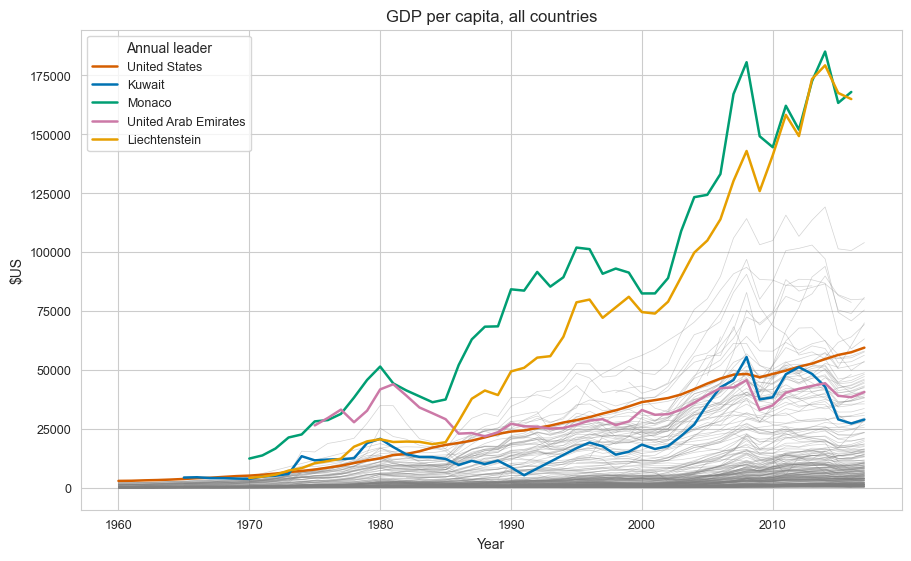

In [4]:
gdp_pc = (
    global_economy
    .assign(y=lambda x: x["GDP"] / x["Population"])
    .dropna(subset=["y"])
)

fig, ax = plt.subplots(figsize=(9, 5.5))
for uid, g in gdp_pc.groupby("unique_id"):
    ax.plot(g["ds"], g["y"], color="grey", lw=0.5, alpha=0.35)

# Highlight the countries that ever held the top spot.
leaders = gdp_pc.loc[gdp_pc.groupby("ds")["y"].idxmax()]
for uid, color in zip(leaders["unique_id"].unique(), [ORANGE, BLUE, GREEN, PINK, "#E69F00"]):
    g = gdp_pc.loc[gdp_pc["unique_id"] == uid]
    ax.plot(g["ds"], g["y"], color=color, lw=1.8, label=uid)

ax.set(title="GDP per capita, all countries", xlabel="Year", ylabel="$US")
ax.legend(title="Annual leader")
plt.show()

In [5]:
# Who leads in each year?
print(leaders.set_index("ds")["unique_id"].to_string())

ds
1960           United States
1961           United States
1962           United States
1963           United States
1964           United States
1965                  Kuwait
1966                  Kuwait
1967           United States
1968           United States
1969           United States
1970                  Monaco
1971                  Monaco
1972                  Monaco
1973                  Monaco
1974                  Monaco
1975                  Monaco
1976    United Arab Emirates
1977    United Arab Emirates
1978                  Monaco
1979                  Monaco
1980                  Monaco
1981                  Monaco
1982                  Monaco
1983                  Monaco
1984                  Monaco
1985                  Monaco
1986                  Monaco
1987                  Monaco
1988                  Monaco
1989                  Monaco
1990                  Monaco
1991                  Monaco
1992                  Monaco
1993                  Monaco
1994       

In [6]:
print("Top 10 in the final year of the data:")
gdp_pc.loc[gdp_pc["ds"] == gdp_pc["ds"].max()].nlargest(10, "y")[["unique_id", "ds", "y"]]

Top 10 in the final year of the data:


,unique_id,ds,y
8403,Luxembourg,2017,104103.037
8461,"Macao SAR, China",2017,80892.821
13439,Switzerland,2017,80189.697
10491,Norway,2017,75504.566
6083,Iceland,2017,70056.873
6605,Ireland,2017,69330.690
11477,Qatar,2017,63249.422
14483,United States,2017,59531.662
10375,North America,2017,58070.066
12143,Singapore,2017,57714.297


In [7]:
# The 2017 table looks surprising -- check whether the usual leaders are even present.
tail = (
    gdp_pc.loc[lambda x: x["unique_id"].isin(["Monaco", "Liechtenstein", "Luxembourg"]) & (x["ds"] >= 2012)]
    .pivot_table(index="ds", columns="unique_id", values="y")
)
print(tail.round(0).to_string())
print("\nGDP reported for Monaco in 2017? ",
      global_economy.loc[(global_economy["unique_id"] == "Monaco") & (global_economy["ds"] == 2017), "GDP"].notna().any())

unique_id  Liechtenstein  Luxembourg    Monaco
ds                                            
2012            149296.0    106749.0  152000.0
2013            173528.0    113625.0  172589.0
2014            179308.0    119225.0  185153.0
2015            167591.0    101447.0  163369.0
2016            164993.0    100739.0  168011.0
2017                 NaN    104103.0       NaN

GDP reported for Monaco in 2017?  False


**Answer.** Measured in current US dollars, **Monaco** has the highest GDP per capita for most of the
period — it leads in every year from 1978 to 2016 apart from 2013 and 2015, when **Liechtenstein**
edges ahead. Earlier in the record the leader changes hands several times: the
United States leads the very early 1960s, **Kuwait** takes over during the 1970s oil boom (1965–66),
and the **United Arab Emirates** leads in 1976–77, before Monaco settles in.

The one trap here is the final year. Luxembourg tops the 2017 table, but only because **neither Monaco
nor Liechtenstein reports GDP for 2017** — the second cell above confirms the values are missing, not
low. So "who leads today" depends on data availability as much as on economics, and the honest
statement is that Monaco leads through the end of the reported record (2016).

Two further points. The leaderboard is dominated by micro-states and oil economies — small populations
make the per-capita ratio very large. And the grey background shows the more important structural
feature: nearly every country trends upward, but the *spread* widens over time, so the gap between the
richest and poorest countries has grown substantially in dollar terms.

---
## Exercise 2

*For each of the following series, make a graph of the data. If transforming seems appropriate, do so
and describe the effect.*

### (a) United States GDP from `global_economy`

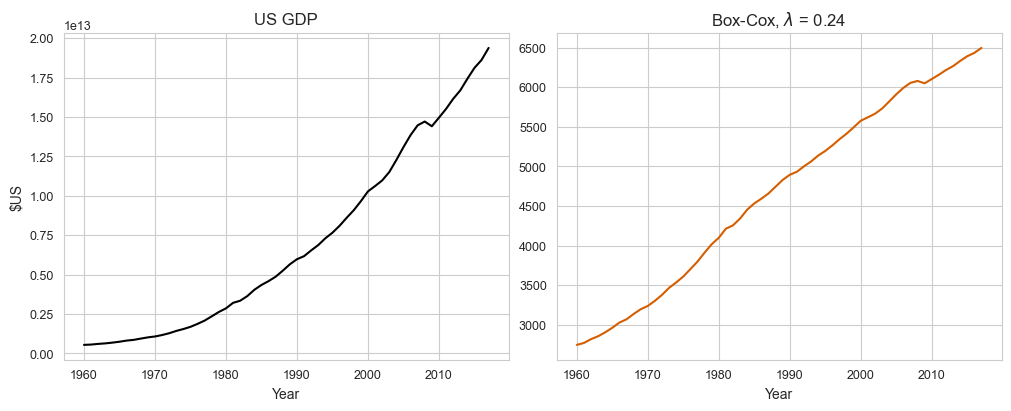

log-likelihood lambda: 0.240


In [8]:
us_gdp = global_economy.loc[lambda x: x["unique_id"] == "United States"].assign(y=lambda x: x["GDP"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_series(us_gdp, "ds", "y", ax=axes[0], title="US GDP", xlabel="Year", ylabel="$US")

lam = boxcox_lambda(us_gdp["y"].to_numpy(), method="loglik")
axes[1].plot(us_gdp["ds"], boxcox(us_gdp["y"].to_numpy(), lam), color=ORANGE)
axes[1].set(title=rf"Box-Cox, $\lambda$ = {lam:.2f}", xlabel="Year", ylabel="")
plt.show()

print(f"log-likelihood lambda: {lam:.3f}")

The raw series is smooth, strictly increasing and has no seasonality, so there is no seasonal variance
to stabilise — a transformation is not really *needed*. The λ chosen does straighten the curve
(growth is roughly exponential, so a small-λ power makes it closer to linear), which would help a
linear-trend model. A more useful adjustment for interpretation is a *population* adjustment
(GDP per capita) or an inflation adjustment, not a mathematical transformation.

### (b) Slaughter of Victorian "Bulls, bullocks and steers" in `aus_livestock`

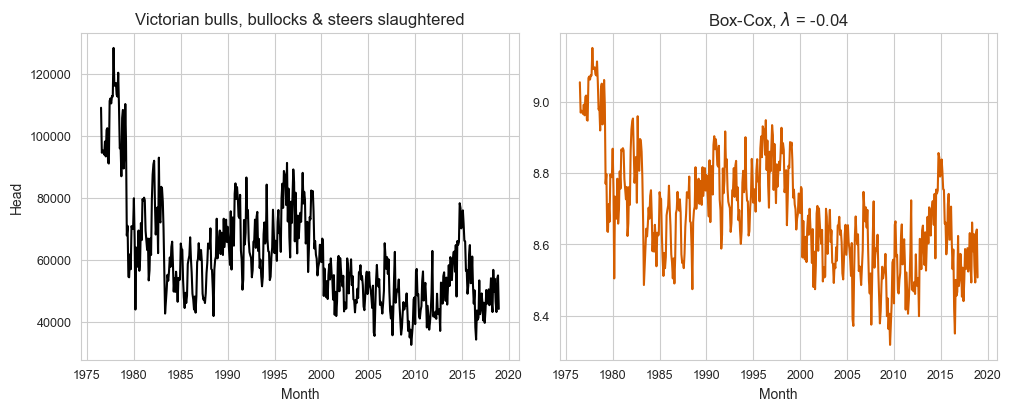

Guerrero lambda: -0.045


In [9]:
vic_bulls = (
    aus_livestock
    .loc[lambda x: (x["Animal"] == "Bulls, bullocks and steers") & (x["State"] == "Victoria")]
    .rename(columns={"Month": "ds", "Count": "y"})
    .sort_values("ds")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_series(vic_bulls, "ds", "y", ax=axes[0],
            title="Victorian bulls, bullocks & steers slaughtered",
            xlabel="Month", ylabel="Head")

lam = boxcox_lambda(vic_bulls["y"].to_numpy(), method="guerrero", season_length=12)
axes[1].plot(vic_bulls["ds"], boxcox(vic_bulls["y"].to_numpy(), lam), color=ORANGE)
axes[1].set(title=rf"Box-Cox, $\lambda$ = {lam:.2f}", xlabel="Month")
plt.show()

print(f"Guerrero lambda: {lam:.3f}")

In [10]:
# Is there really a level-variance relationship to fix?
s = vic_bulls.set_index("ds")["y"]
by_year = s.groupby(s.index.year).agg(level="mean", seasonal_range=lambda x: x.max() - x.min())
print(f"corr(annual level, annual range) = {by_year['level'].corr(by_year['seasonal_range']):.3f}\n")


def range_cv(values, index, lam):
    z = pd.Series(boxcox(values, lam), index=index)
    r = z.groupby(index.year).agg(lambda x: x.max() - x.min())
    return r.std() / r.mean()


idx = pd.DatetimeIndex(vic_bulls["ds"])
vals = vic_bulls["y"].to_numpy(dtype=float)
print(f"{'lambda':>8}  {'CV of yearly range':>20}")
for L in [0.0, lam, 0.5, 1.0]:
    print(f"{L:>8.3f}  {range_cv(vals, idx, L):>20.4f}")

corr(annual level, annual range) = 0.492

  lambda    CV of yearly range
   0.000                0.2814
  -0.045                0.2818
   0.500                0.2984
   1.000                0.3537


Guerrero selects a λ just below zero, i.e. effectively a **log transformation** — not the "leave it
alone" answer the plot might suggest. But the case is weak: the correlation between the annual level
and the annual seasonal range is only about 0.5, and moving from λ = 1 to λ = 0 improves the
consistency of the seasonal swing only modestly (the CV of the yearly range falls from about 0.35 to
0.28). The transformed plot is close to a rescaled copy of the original.

So a log is mildly defensible — it evens out the high-variance early years a little — but this series
is perfectly usable untransformed, and the interpretability cost of transforming probably is not worth
it.

### (c) Victorian Electricity Demand from `vic_elec`

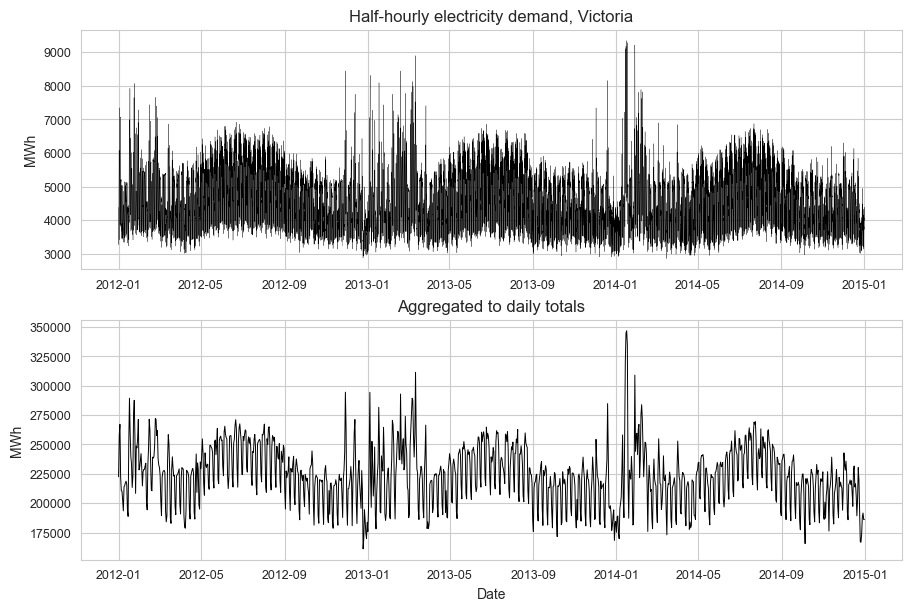

Guerrero lambda (daily): -0.900   (the search is bounded to [-0.9, 2.0])


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6))
axes[0].plot(vic_elec["Time"], vic_elec["Demand"], color=BLACK, lw=0.2)
axes[0].set(title="Half-hourly electricity demand, Victoria", ylabel="MWh")

daily_elec = (
    vic_elec.assign(ds=lambda x: x["Time"].dt.normalize())
    .groupby("ds", as_index=False)["Demand"].sum()
)
axes[1].plot(daily_elec["ds"], daily_elec["Demand"], color=BLACK, lw=0.7)
axes[1].set(title="Aggregated to daily totals", xlabel="Date", ylabel="MWh")
plt.show()

lam = boxcox_lambda(daily_elec["Demand"].to_numpy(), method="guerrero", season_length=7)
print(f"Guerrero lambda (daily): {lam:.3f}   (the search is bounded to [-0.9, 2.0])")

In [12]:
d = daily_elec.set_index("ds")["Demand"]
print(f"max / median = {d.max() / d.median():.2f}      skewness = {d.skew():.3f}\n")
print(f"{'lambda':>8}  {'skewness after transform':>26}")
for L in [-0.9, 0.0, 0.5, 1.0]:
    print(f"{L:>8.2f}  {pd.Series(boxcox(d.to_numpy(), L)).skew():>26.3f}")

max / median = 1.55      skewness = 0.312

  lambda    skewness after transform
   -0.90                       0.000
    0.00                      -0.086
    0.50                       0.102
    1.00                       0.312


The half-hourly series is dominated by strong daily and weekly seasonality plus summer spikes driven
by temperature. The size of the fluctuations does not scale with the level — the summer peaks are
weather events, not proportional growth — so a Box-Cox transformation does not address the real
structure here.

The λ is worth a second look: it comes back at **−0.9, exactly the lower bound of the search**. A
value pinned to a bound means the criterion wanted to keep going, which is a red flag rather than a
recommendation. The second cell shows what it is actually chasing: daily demand is only mildly
right-skewed (skewness ≈ 0.3, max only 1.55× the median), and λ = −0.9 happens to drive that skewness
to zero. That is cosmetic — it is not stabilising a variance that grows with the level, because there
is no such growth.

What *does* help is aggregating to a coarser frequency (daily, above) so the annual pattern becomes
readable, and modelling temperature as a covariate.

### (d) Gas production from `aus_production`

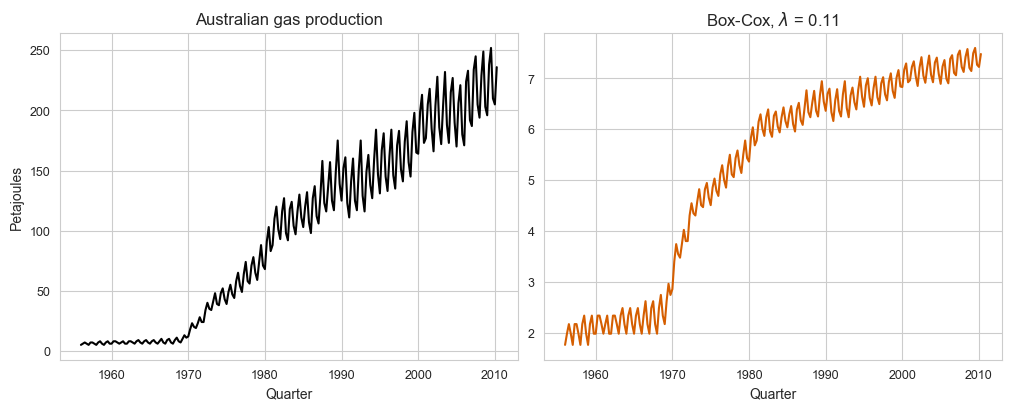

Guerrero lambda: 0.110


In [13]:
aus_gas = aus_production[["ds", "Gas"]].rename(columns={"Gas": "y"}).assign(unique_id="Gas")
y = aus_gas["y"].to_numpy()
lam_gas = boxcox_lambda(y, method="guerrero", season_length=4)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_series(aus_gas, "ds", "y", ax=axes[0], title="Australian gas production",
            xlabel="Quarter", ylabel="Petajoules")
axes[1].plot(aus_gas["ds"], boxcox(y, lam_gas), color=ORANGE)
axes[1].set(title=rf"Box-Cox, $\lambda$ = {lam_gas:.2f}", xlabel="Quarter")
plt.show()

print(f"Guerrero lambda: {lam_gas:.3f}")

This is the textbook case *for* transforming. In the raw data the seasonal swings are tiny in the
1950s and enormous by 2010 — the seasonal amplitude is proportional to the level. With the small λ
selected (close to a log) the seasonal fluctuation becomes roughly the same size throughout the
series, which is exactly what an additive model needs.

---
## Exercise 3

*Why is a Box-Cox transformation unhelpful for the `canadian_gas` data?*

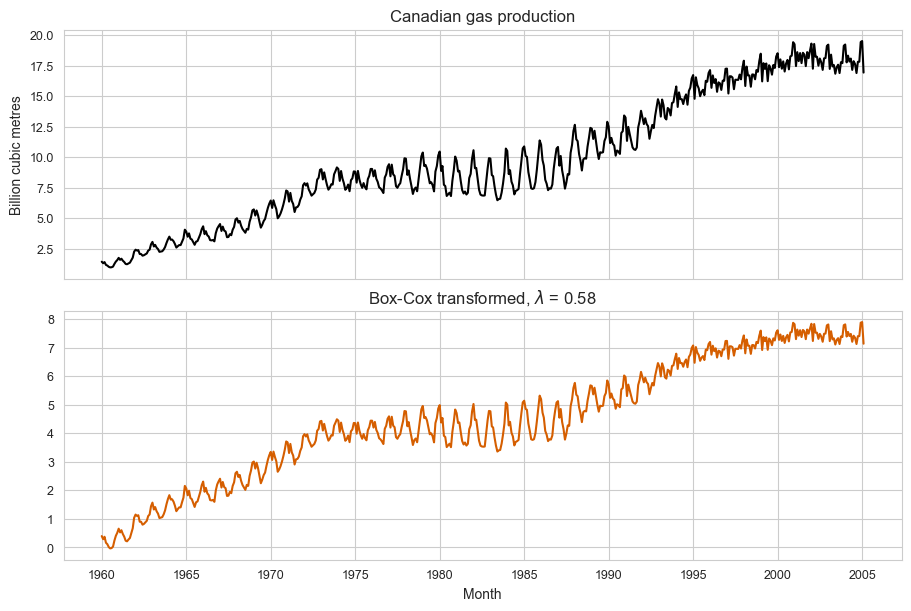

Guerrero lambda: 0.577


In [14]:
cgas = canadian_gas.rename(columns={"Month": "ds", "Volume": "y"}).assign(unique_id="canadian_gas")

lam_c = boxcox_lambda(cgas["y"].to_numpy(), method="guerrero", season_length=12)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(cgas["ds"], cgas["y"], color=BLACK)
axes[0].set(title="Canadian gas production", ylabel="Billion cubic metres")
axes[1].plot(cgas["ds"], boxcox(cgas["y"].to_numpy(), lam_c), color=ORANGE)
axes[1].set(title=rf"Box-Cox transformed, $\lambda$ = {lam_c:.2f}", xlabel="Month", ylabel="")
plt.show()

print(f"Guerrero lambda: {lam_c:.3f}")

In [15]:
# Seasonal amplitude against the level of the series, decade by decade.
amp = (
    cgas.assign(year=lambda x: x["ds"].dt.year)
    .assign(decade=lambda x: (x["year"] // 10) * 10)
    .groupby(["decade", "year"])["y"]
    .agg(level="mean", peak_to_trough=lambda s: s.max() - s.min())
    .groupby("decade")
    .mean()
)
amp["relative"] = amp["peak_to_trough"] / amp["level"]
amp.round(3)

,level,peak_to_trough,relative
decade,,,
1960,3.158,1.282,0.406
1970,7.836,2.275,0.290
1980,9.034,3.756,0.416
1990,14.808,2.470,0.167
2000,18.068,2.311,0.128


In [16]:
# The same thing year by year, so the turning point is visible.
per_year = (
    cgas.assign(year=lambda x: x["ds"].dt.year)
    .groupby("year")["y"]
    .agg(level="mean", peak_to_trough=lambda s: s.max() - s.min())
)
print(f"Absolute seasonal amplitude peaks in {per_year['peak_to_trough'].idxmax()} "
      f"at {per_year['peak_to_trough'].max():.2f}, "
      f"while the level keeps rising to {per_year['level'].iloc[-1]:.2f} by "
      f"{per_year.index[-1]}.\n")
print(per_year.loc[[1962, 1970, 1980, 1987, 1995, 2000, 2004]].round(3).to_string())

Absolute seasonal amplitude peaks in 1987 at 4.72, while the level keeps rising to 18.24 by 2005.

       level  peak_to_trough
year                        
1962   2.244           0.929
1970   5.986           2.278
1980   8.228           3.652
1987   9.463           4.724
1995  15.835           2.115
2000  17.916           2.405
2004  18.000           2.546


**Answer.** A Box-Cox transformation applies a single *monotonic* re-scaling to the whole series, so it
can only fix seasonal variation that moves in **one direction** with the level. The Canadian gas data
does not behave that way. In absolute terms the seasonal amplitude grows from about 0.6 in the early
1960s to a peak of about 4.7 in 1987, and then **falls back** to roughly 2.5 by 2005 — even though the
level of the series *keeps rising* the whole time, from about 1.2 to about 18. Relative to the level
the collapse is even starker: the decade table shows the ratio around 0.4 in the 1980s and about 0.13
by the 2000s.

Because the relationship between variance and level is non-monotonic — variance rises with the level,
then falls with the level — no single λ can flatten it. A λ small enough to tame the 1980s bulge
over-shrinks the post-1990 portion, and a λ near 1 leaves the bulge in place. Guerrero's compromise
(λ ≈ 0.58) does neither job well, which is exactly why the transformed plot above still shows a
pronounced mid-series bulge.

This series needs a model with time-varying seasonality (e.g. STL, as in Exercise 10), not a static
transformation.

---
## Exercise 4

*What Box-Cox transformation would you select for your retail data (from Exercise 7 in Section 2.10)?*

Section 2.10 Exercise 7 asks you to pick a random `Series ID` from `aus_retail`. Reproduced here with
a fixed seed so the notebook is deterministic.

In [17]:
rng = np.random.default_rng(12345678)
series_id = rng.choice(np.sort(aus_retail["Series ID"].unique()))

myseries = (
    aus_retail
    .loc[lambda x: x["Series ID"] == series_id]
    .rename(columns={"Month": "ds", "Turnover": "y"})
    .assign(unique_id=series_id)
    .sort_values("ds")
    .reset_index(drop=True)
)
print(f"Series ID : {series_id}")
print(f"State     : {myseries['State'].iloc[0]}")
print(f"Industry  : {myseries['Industry'].iloc[0]}")
print(f"Period    : {myseries['ds'].min():%Y-%m} to {myseries['ds'].max():%Y-%m}  ({len(myseries)} obs)")

Series ID : A3349908R
State     : Western Australia
Industry  : Other retailing n.e.c.
Period    : 1982-04 to 2018-12  (441 obs)


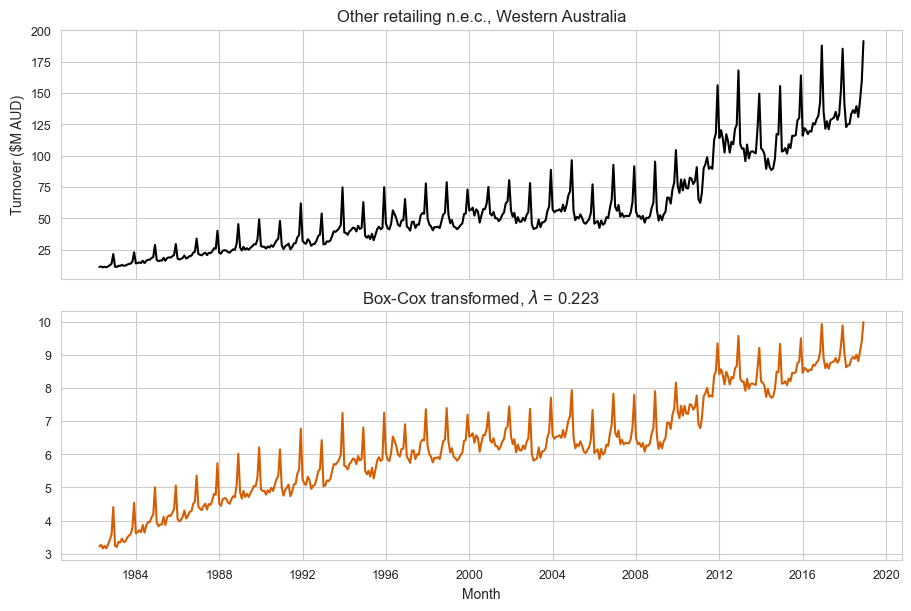

Guerrero lambda: 0.2234


In [18]:
lam_retail = boxcox_lambda(myseries["y"].to_numpy(), method="guerrero", season_length=12)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(myseries["ds"], myseries["y"], color=BLACK)
axes[0].set(title=f"{myseries['Industry'].iloc[0]}, {myseries['State'].iloc[0]}",
            ylabel="Turnover ($M AUD)")
axes[1].plot(myseries["ds"], boxcox(myseries["y"].to_numpy(), lam_retail), color=ORANGE)
axes[1].set(title=rf"Box-Cox transformed, $\lambda$ = {lam_retail:.3f}", xlabel="Month", ylabel="")
plt.show()

print(f"Guerrero lambda: {lam_retail:.4f}")

In [19]:
# Compare a few candidate lambdas by how constant the seasonal swing is across the series.
def seasonal_amplitude_cv(values, index, lam):
    z = pd.Series(boxcox(values, lam), index=index)
    yearly = z.groupby(index.year).agg(lambda s: s.max() - s.min())
    return yearly.std() / yearly.mean()

idx = pd.DatetimeIndex(myseries["ds"])
vals = myseries["y"].to_numpy()
print(f"{'lambda':>8}  {'CV of yearly seasonal range':>28}")
for lam in [0.0, lam_retail, 0.25, 0.5, 1.0]:
    print(f"{lam:>8.3f}  {seasonal_amplitude_cv(vals, idx, lam):>28.4f}")

  lambda   CV of yearly seasonal range
   0.000                        0.2416
   0.223                        0.2294
   0.250                        0.2324
   0.500                        0.2950
   1.000                        0.5079


**Answer.** Guerrero's method selects **λ ≈ 0.22** for this series (Western Australia, "Other retailing
n.e.c.") — roughly a fourth-root transformation. The check above confirms that this is a genuine
optimum rather than an artefact: the year-to-year variability of the seasonal swing is lowest around
λ ≈ 0.22, rises only slightly at λ = 0, and then climbs steeply towards λ = 1.

In practice **λ = 0, a plain log, is the choice I would make**. It scores almost identically
(CV 0.242 vs 0.229), it is far easier to explain and back-transform, and it puts the model on a
constant-percentage-growth footing that suits retail turnover. Either way the important point stands:
in the raw data the December peaks grow with the level of turnover, and after transforming the
seasonal swing is roughly constant across the whole 37 years.

---
## Exercise 5

*For the following series, find an appropriate Box-Cox transformation in order to stabilise the
variance: Tobacco from `aus_production`, Economy class passengers between Melbourne and Sydney from
`ansett`, and Pedestrian counts at Southern Cross Station from `pedestrian`.*

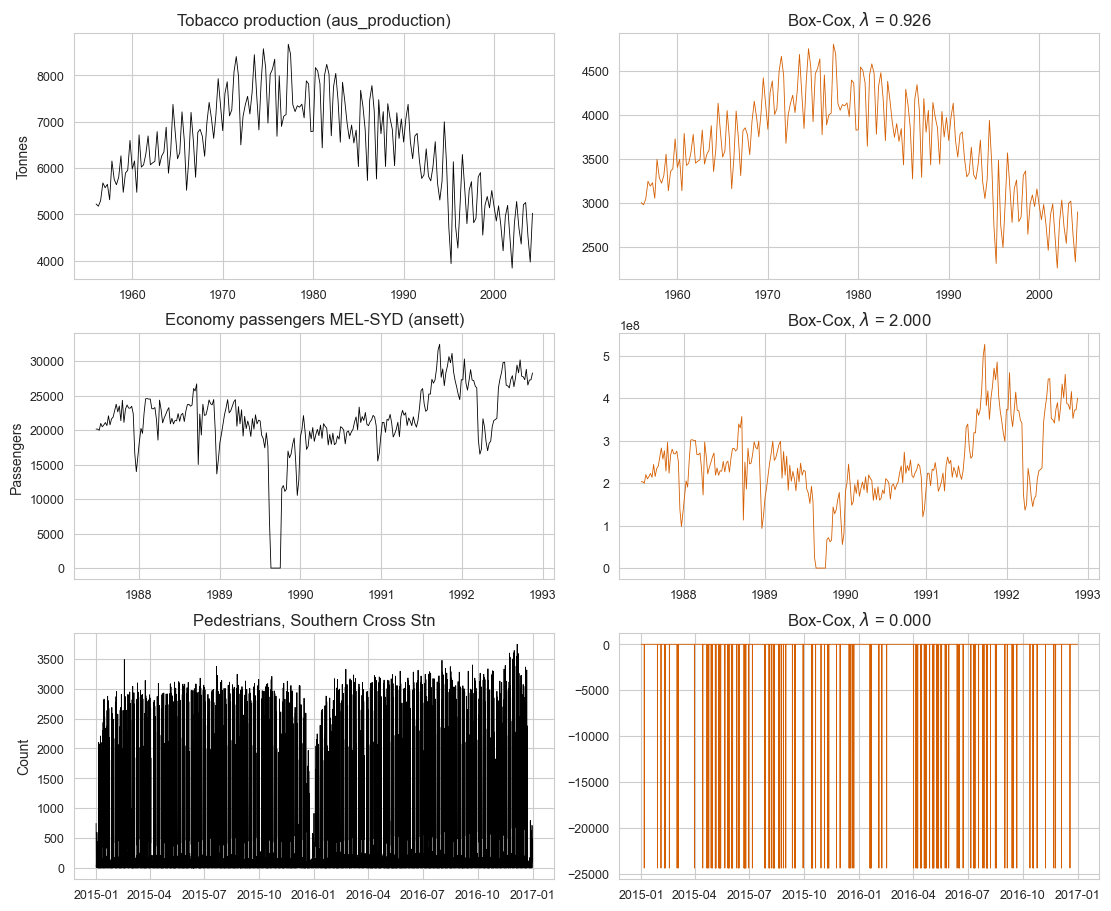

Tobacco production (aus_production)      lambda = 0.9265
Economy passengers MEL-SYD (ansett)      lambda = 2.0000
Pedestrians, Southern Cross Stn          lambda = 0.0000


In [20]:
tobacco = (
    aus_production[["ds", "Tobacco"]]
    .rename(columns={"Tobacco": "y"})
    .dropna()
    .reset_index(drop=True)
)

mel_syd_economy = (
    ansett
    .loc[lambda x: (x["Airports"] == "MEL-SYD") & (x["Class"] == "Economy")]
    .rename(columns={"Week": "ds", "Passengers": "y"})
    .sort_values("ds")
    .reset_index(drop=True)
)

southern_cross = (
    pedestrian
    .loc[lambda x: x["Sensor"] == "Southern Cross Station"]
    .rename(columns={"Date_Time": "ds", "Count": "y"})
    .sort_values("ds")
    .reset_index(drop=True)
)

series = [
    ("Tobacco production (aus_production)", tobacco, 4, "Tonnes"),
    ("Economy passengers MEL-SYD (ansett)", mel_syd_economy, 52, "Passengers"),
    ("Pedestrians, Southern Cross Stn", southern_cross, 24, "Count"),
]

lambdas = {}
fig, axes = plt.subplots(3, 2, figsize=(11, 9))
for (name, df, m, unit), row in zip(series, axes):
    yv = df["y"].to_numpy(dtype=float)
    lam = boxcox_lambda(yv, method="guerrero", season_length=m)
    lambdas[name] = lam
    row[0].plot(df["ds"], yv, color=BLACK, lw=0.6)
    row[0].set(title=name, ylabel=unit)
    row[1].plot(df["ds"], boxcox(yv, lam), color=ORANGE, lw=0.6)
    row[1].set(title=rf"Box-Cox, $\lambda$ = {lam:.3f}")
plt.show()

for k, v in lambdas.items():
    print(f"{k:<40} lambda = {v:.4f}")

In [21]:
print("ansett MEL-SYD economy: zero-passenger weeks")
zero_weeks = mel_syd_economy.loc[mel_syd_economy["y"] == 0, "ds"]
print(f"  {len(zero_weeks)} weeks, {zero_weeks.min():%Y-%m-%d} to {zero_weeks.max():%Y-%m-%d}")
print(f"\npedestrian Southern Cross: {(southern_cross['y'] == 0).sum()} zero counts "
      f"out of {len(southern_cross)}")
print(f"  hourly range: {southern_cross['y'].min()} to {southern_cross['y'].max()}")

ansett MEL-SYD economy: zero-passenger weeks
  7 weeks, 1989-08-21 to 1989-10-02

pedestrian Southern Cross: 159 zero counts out of 17539
  hourly range: 0 to 3743


**Answer.**

| Series | seasonal period | Guerrero λ | Recommendation |
|---|---|---|---|
| Tobacco (`aus_production`) | 4 (quarterly) | **0.93** | close to 1 — **no transformation needed**; the variance is already roughly stable |
| MEL–SYD economy (`ansett`) | 52 (weekly) | **2.00**, pinned at the upper bound | no power transform helps — the series contains seven consecutive *zero*-passenger weeks (21 Aug – 2 Oct 1989, the Australian pilots' dispute), so the problem is a structural break, not heteroscedasticity |
| Southern Cross (`pedestrian`) | 24 (hourly) | **0.00** | exactly a **log transformation**; it pulls the huge daytime peaks and the near-empty overnight hours into a comparable range |

Two practical notes. `boxcox_lambda` bounds λ to [−0.9, 2.0], so a value sitting exactly on a bound
(as with `ansett`) is a warning sign that the transformation is being asked to fix something it
cannot — for that series the honest answer is "none is appropriate; handle the strike period
explicitly". And the pedestrian counts contain 159 exact zeros, at which $\log y$ is undefined, so in
practice you would model $\log(y + 1)$ or treat the overnight hours separately.

---
## Exercise 6

*Show that a $3\times5$ MA is equivalent to a 7-term weighted moving average with weights
0.067, 0.133, 0.200, 0.200, 0.200, 0.133, 0.067.*

**Algebraically.** Let $u_t = \tfrac15\sum_{j=-2}^{2} y_{t+j}$ be the 5-MA. The $3\times5$ MA is a
3-MA of that:

$$\hat T_t = \tfrac13\left(u_{t-1} + u_t + u_{t+1}\right)
 = \tfrac{1}{15}\sum_{j=-3}^{3} c_j\, y_{t+j}$$

where $c_j$ counts how many of the three 5-term windows contain $y_{t+j}$: the centre three
observations appear in all 3 windows, the next ones out in 2, and the outermost in 1. So

$$\hat T_t = \tfrac{1}{15}y_{t-3} + \tfrac{2}{15}y_{t-2} + \tfrac{3}{15}y_{t-1}
 + \tfrac{3}{15}y_{t} + \tfrac{3}{15}y_{t+1} + \tfrac{2}{15}y_{t+2} + \tfrac{1}{15}y_{t+3}$$

and $\tfrac{1}{15} = 0.0\overline{6}$, $\tfrac{2}{15} = 0.1\overline{3}$, $\tfrac{3}{15} = 0.2$ —
exactly the stated weights. Now verify numerically.

In [22]:
# Derive the weights by convolving the two rectangular kernels.
k5 = np.ones(5) / 5
k3 = np.ones(3) / 3
weights = np.convolve(k5, k3)

print("Implied weights :", np.round(weights, 3))
print("Stated weights  :", np.array([0.067, 0.133, 0.200, 0.200, 0.200, 0.133, 0.067]))
print("Exact fractions :", [f"{int(round(w * 15))}/15" for w in weights])
print("Sum             :", weights.sum())

Implied weights : [0.067 0.133 0.2   0.2   0.2   0.133 0.067]
Stated weights  : [0.067 0.133 0.2   0.2   0.2   0.133 0.067]
Exact fractions : ['1/15', '2/15', '3/15', '3/15', '3/15', '2/15', '1/15']
Sum             : 1.0


In [23]:
# And confirm on real data.
ex = aus_production[["ds", "Beer"]].dropna().reset_index(drop=True)
y = ex["Beer"]

ma_3x5 = y.rolling(5, center=True).mean().rolling(3, center=True).mean()
ma_w7 = y.rolling(7, center=True).apply(lambda w: np.dot(w, weights), raw=True)

comparison = pd.DataFrame({"ds": ex["ds"], "3x5-MA": ma_3x5, "weighted 7-MA": ma_w7})
comparison["difference"] = comparison["3x5-MA"] - comparison["weighted 7-MA"]

print(comparison.dropna().head(8).to_string(index=False))
print(f"\nMax absolute difference: {comparison['difference'].abs().max():.3e}")

        ds  3x5-MA  weighted 7-MA  difference
1956-10-01 252.867        252.867   0.000e+00
1957-01-01 256.867        256.867  -5.684e-14
1957-04-01 262.200        262.200   0.000e+00
1957-07-01 264.067        264.067   0.000e+00
1957-10-01 260.333        260.333   0.000e+00
1958-01-01 264.133        264.133   0.000e+00
1958-04-01 265.933        265.933   0.000e+00
1958-07-01 264.133        264.133   0.000e+00

Max absolute difference: 1.137e-13


The two are identical to floating-point precision.

---
## Exercise 7

*Consider the last five years of the Gas data from `aus_production`.*

```python
gas = aus_production.loc[lambda x: x["unique_id"] == "Gas"].tail(5 * 4)
```

In [24]:
gas = (
    aus_production_long
    .loc[lambda x: x["unique_id"] == "Gas"]
    .tail(5 * 4)
    .reset_index(drop=True)
)
gas

,ds,unique_id,y
0,2005-07-01,Gas,221.0
1,2005-10-01,Gas,180.0
2,2006-01-01,Gas,171.0
3,2006-04-01,Gas,224.0
4,2006-07-01,Gas,233.0
5,2006-10-01,Gas,192.0
6,2007-01-01,Gas,187.0
7,2007-04-01,Gas,234.0
8,2007-07-01,Gas,245.0
9,2007-10-01,Gas,205.0


### (a) Plot the time series. Can you identify seasonal fluctuations and/or a trend-cycle?

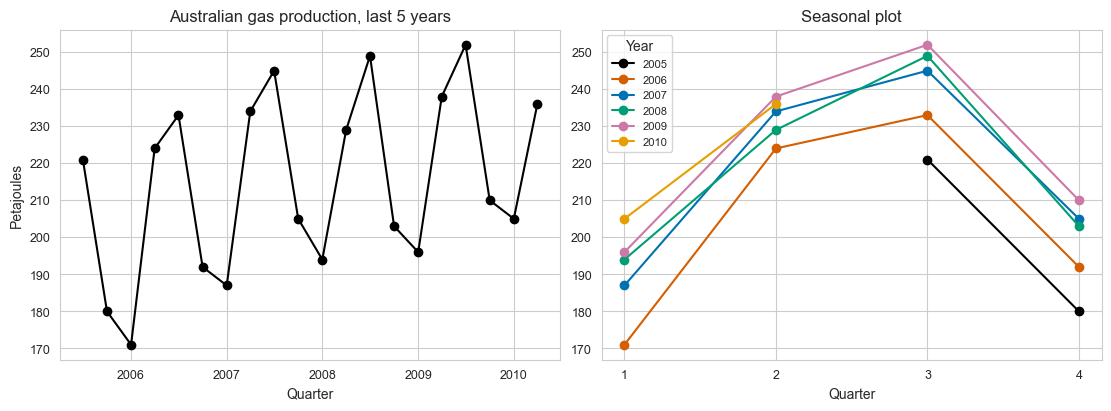

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(gas["ds"], gas["y"], marker="o", color=BLACK)
axes[0].set(title="Australian gas production, last 5 years", xlabel="Quarter", ylabel="Petajoules")

# Seasonal plot: one line per year, quarter on the x-axis.
gas_seasonal = gas.assign(year=lambda x: x["ds"].dt.year, quarter=lambda x: x["ds"].dt.quarter)
palette = [BLACK, ORANGE, BLUE, GREEN, PINK, "#E69F00"]
for (yr, g), color in zip(gas_seasonal.groupby("year"), palette):
    axes[1].plot(g["quarter"], g["y"], marker="o", label=str(yr), color=color)
axes[1].set(title="Seasonal plot", xlabel="Quarter", ylabel="", xticks=[1, 2, 3, 4])
axes[1].legend(title="Year", fontsize=8)
plt.show()

**Answer.** Both are clearly present. There is a strong, very regular **seasonal pattern**: production
peaks in Q3 (the southern-hemisphere winter, when heating demand is highest) and troughs in Q1. There
is also a mild upward **trend-cycle** — the whole seasonal profile shifts up year on year in the
seasonal plot. The seasonal swing is large relative to the trend movement, roughly ±10% of the level.

### (b) Use `seasonal_decompose` with `model='multiplicative'` to calculate the trend-cycle and seasonal indices.

In [26]:
gas_ts = gas.set_index("ds")["y"].asfreq("QS")
res = seasonal_decompose(gas_ts, model="multiplicative", period=4)

dcmp = pd.DataFrame({
    "ds": gas["ds"],
    "data": gas["y"].to_numpy(),
    "trend": res.trend.to_numpy(),
    "seasonal": res.seasonal.to_numpy(),
    "remainder": res.resid.to_numpy(),
})
dcmp

,ds,data,trend,seasonal,remainder
0,2005-07-01,221.0,NaN,1.126,NaN
1,2005-10-01,180.0,NaN,0.925,NaN
2,2006-01-01,171.0,200.500,0.875,0.974
3,2006-04-01,224.0,203.500,1.074,1.025
4,2006-07-01,233.0,207.000,1.126,1.000
5,2006-10-01,192.0,210.250,0.925,0.987
6,2007-01-01,187.0,213.000,0.875,1.003
7,2007-04-01,234.0,216.125,1.074,1.008
8,2007-07-01,245.0,218.625,1.126,0.996
9,2007-10-01,205.0,218.875,0.925,1.012


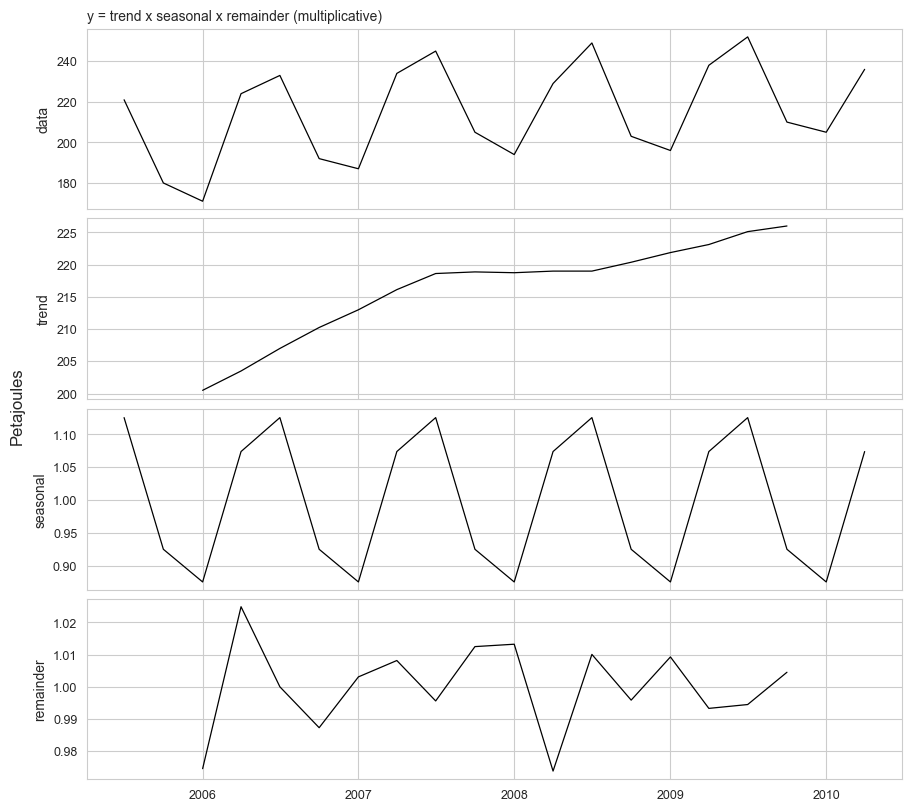

Seasonal indices:
q
1    0.875
2    1.074
3    1.126
4    0.925


In [27]:
decomposition_plot(dcmp, ["data", "trend", "seasonal", "remainder"],
                   "y = trend x seasonal x remainder (multiplicative)",
                   ylabel="Petajoules")
plt.show()

print("Seasonal indices:")
print(dcmp.assign(q=lambda x: x["ds"].dt.quarter).groupby("q")["seasonal"].first().round(4).to_string())

### (c) Do the results support the graphical interpretation from part (a)?

**Yes.** The estimated trend-cycle rises steadily before flattening near the end, matching the drift
seen in part (a). The seasonal indices put Q3 well above 1 and Q1 well below it, with Q2 and Q4 in
between — the same winter-peak / summer-trough shape the seasonal plot showed, and of the same
magnitude (roughly ±10%). The remainder stays within a few percent of 1 and shows no obvious
structure, so trend and seasonality between them account for nearly all the variation.

### (d) Compute and plot the seasonally adjusted data.

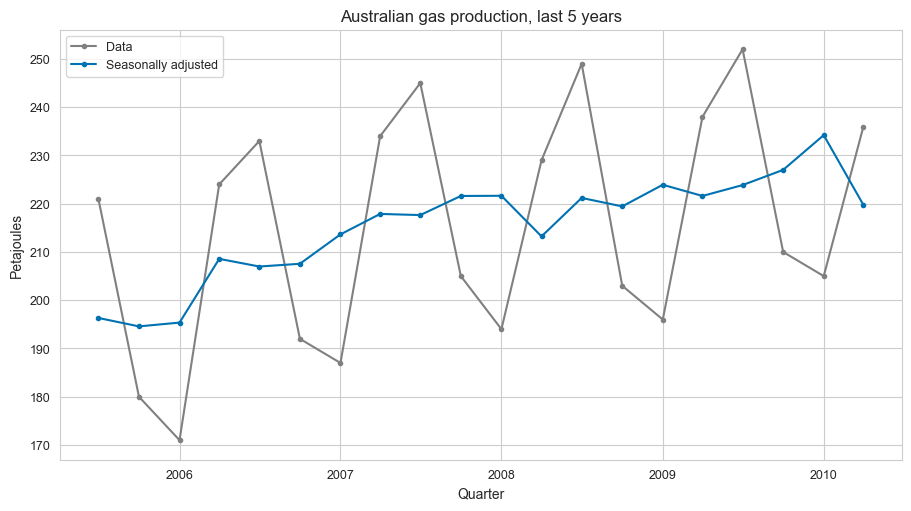

In [28]:
dcmp["seas_adj"] = dcmp["data"] / dcmp["seasonal"]

fig, ax = plt.subplots()
ax.plot(dcmp["ds"], dcmp["data"], color="grey", marker="o", ms=3, label="Data")
ax.plot(dcmp["ds"], dcmp["seas_adj"], color=BLUE, marker="o", ms=3, label="Seasonally adjusted")
ax.set(title="Australian gas production, last 5 years", xlabel="Quarter", ylabel="Petajoules")
ax.legend()
plt.show()

### (e) Change one observation to be an outlier (add 300 to one observation) and recompute the seasonally adjusted data. What is the effect?

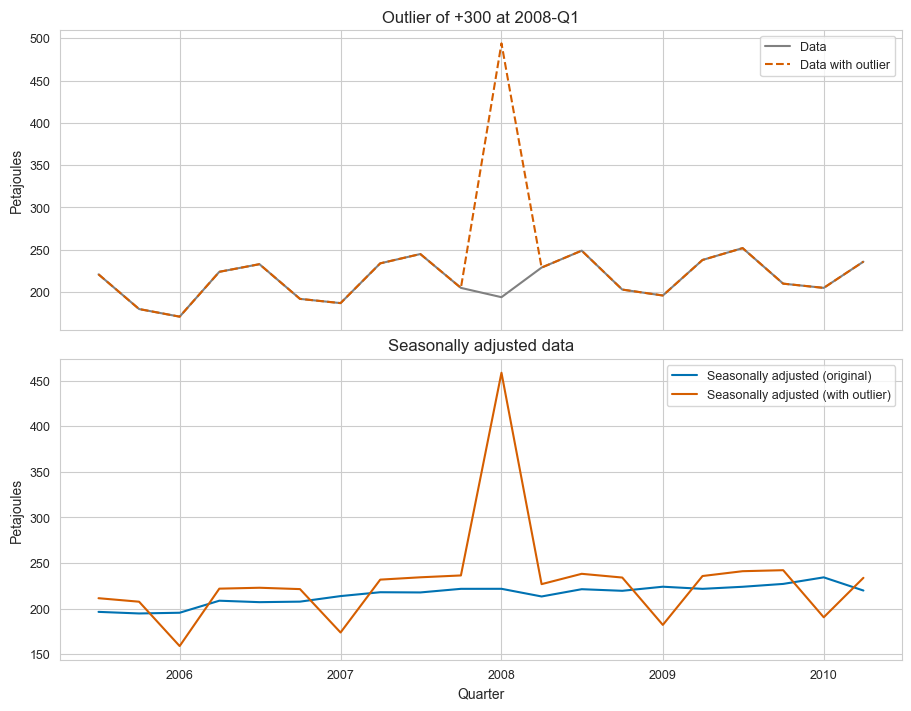

Seasonal indices, original vs. mid-series outlier:
 quarter  original  with_outlier
       3     1.126         1.046
       4     0.925         0.868
       1     0.875         1.077
       2     1.074         1.010


In [29]:
def seasonally_adjust(s, period=4):
    r = seasonal_decompose(s, model="multiplicative", period=period)
    return s / r.seasonal, r.seasonal


gas_mid = gas_ts.copy()
mid_pos = len(gas_mid) // 2
gas_mid.iloc[mid_pos] += 300

sa_orig, seas_orig = seasonally_adjust(gas_ts)
sa_mid, seas_mid = seasonally_adjust(gas_mid)

stamp = gas_mid.index[mid_pos]
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(gas_ts.index, gas_ts.values, color="grey", label="Data")
axes[0].plot(gas_mid.index, gas_mid.values, color=ORANGE, ls="--", label="Data with outlier")
axes[0].set(title=f"Outlier of +300 at {stamp.year}-Q{stamp.quarter}", ylabel="Petajoules")
axes[0].legend()

axes[1].plot(sa_orig.index, sa_orig.values, color=BLUE, label="Seasonally adjusted (original)")
axes[1].plot(sa_mid.index, sa_mid.values, color=ORANGE, label="Seasonally adjusted (with outlier)")
axes[1].set(title="Seasonally adjusted data", xlabel="Quarter", ylabel="Petajoules")
axes[1].legend()
plt.show()

print("Seasonal indices, original vs. mid-series outlier:")
print(pd.DataFrame({
    "quarter": gas_ts.index.quarter[:4],
    "original": seas_orig.values[:4].round(4),
    "with_outlier": seas_mid.values[:4].round(4),
}).to_string(index=False))

**Effect of the outlier.** Two things happen at once.

1. **A huge local spike.** The seasonally adjusted value at the contaminated quarter jumps by roughly
   +300 (divided by that quarter's seasonal index). Seasonal adjustment removes only the seasonal
   component — it does not remove outliers, so the spike stays.
2. **Contamination of the whole series.** `seasonal_decompose` estimates one seasonal index per
   quarter by averaging the detrended values across *all* years. The +300 inflates the index for
   whichever quarter it landed in, so **every** observation in that quarter — in all five years — gets
   divided by a wrong number and shifts. The 2×4-MA trend estimate is also dragged upward for two
   quarters either side, which distorts the neighbouring adjustments too.

So a single bad observation damages the entire seasonally adjusted series, not just its own point.

### (f) Does it make any difference if the outlier is near the end rather than in the middle?

Trend-cycle is estimated for positions 2..17 of 0..19; the rest are NaN.


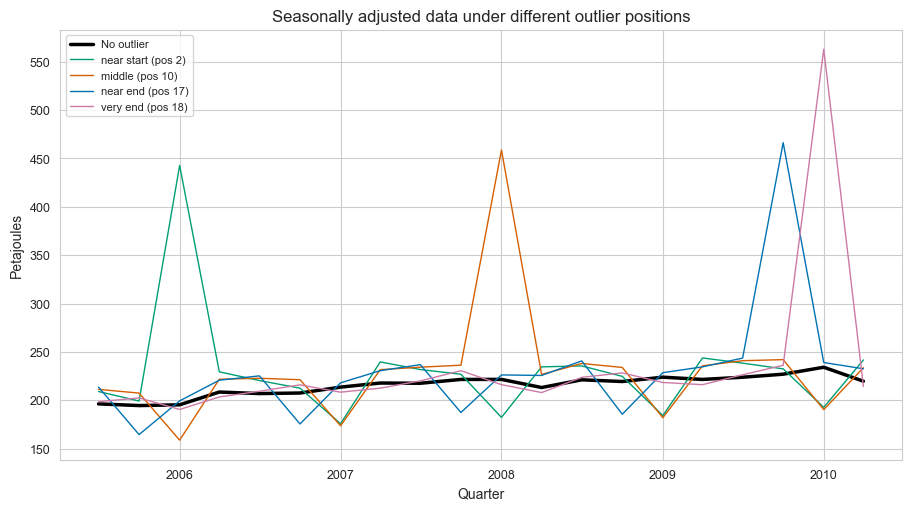

In [30]:
# The centred 2x4-MA is undefined for the first two and last two observations, so
# note which positions actually contribute to the seasonal index estimate.
valid = np.flatnonzero(res.trend.notna().to_numpy())
print(f"Trend-cycle is estimated for positions {valid.min()}..{valid.max()} of "
      f"0..{len(gas_ts) - 1}; the rest are NaN.")

positions = {"near start (pos 2)": 2, "middle (pos 10)": 10,
             "near end (pos 17)": 17, "very end (pos 18)": 18}

scenarios = {}
for label, pos in positions.items():
    g = gas_ts.copy()
    g.iloc[pos] += 300
    scenarios[label] = (pos,) + seasonally_adjust(g)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sa_orig.index, sa_orig.values, color=BLACK, lw=2.5, label="No outlier")
for (label, (pos, adj, _)), color in zip(scenarios.items(), [GREEN, ORANGE, BLUE, PINK]):
    ax.plot(adj.index, adj.values, color=color, lw=1, label=label)
ax.set(title="Seasonally adjusted data under different outlier positions",
       xlabel="Quarter", ylabel="Petajoules")
ax.legend(fontsize=8)
plt.show()

In [31]:
rows = []
for label, (pos, adj, seas) in scenarios.items():
    diff = (adj - sa_orig).abs()
    spill = diff.drop(diff.index[pos])          # damage to the OTHER observations
    rows.append({
        "scenario": label,
        "quarter hit": gas_ts.index[pos].quarter,
        "trend estimated?": "yes" if pos in valid else "no",
        "spike at the point": round(diff.iloc[pos], 1),
        "spill-over mean": round(spill.mean(), 2),
        "spill-over max": round(spill.max(), 2),
        "max shift in a seasonal index": round(float(np.abs(seas.values[:4] - seas_orig.values[:4]).max()), 4),
    })
print(pd.DataFrame(rows).to_string(index=False))

          scenario  quarter hit trend estimated?  spike at the point  spill-over mean  spill-over max  max shift in a seasonal index
near start (pos 2)            1              yes               247.4            19.04           41.49                          0.188
   middle (pos 10)            1              yes               237.1            20.17           43.83                          0.202
 near end (pos 17)            4              yes               239.3            16.32           34.16                          0.169
 very end (pos 18)            1               no               328.6             5.42            9.23                          0.036


In [32]:
print("Seasonal indices under each scenario (note the series starts in Q3):")
tbl = {"quarter": gas_ts.index.quarter[:4], "clean": seas_orig.values[:4].round(4)}
for label, (pos, adj, seas) in scenarios.items():
    tbl[label.split(" (")[0]] = seas.values[:4].round(4)
print(pd.DataFrame(tbl).to_string(index=False))

Seasonal indices under each scenario (note the series starts in Q3):
 quarter  clean  near start  middle  near end  very end
       3  1.126       1.057   1.046     1.034     1.113
       4  0.925       0.903   0.868     1.094     0.889
       1  0.875       1.064   1.077     0.858     0.897
       2  1.074       0.976   1.010     1.015     1.101


**Answer.** Yes — but the interesting difference is not the one you might expect.

- **Anywhere the observation actually contributes to the estimate, position barely matters.** For
  outliers at positions 2, 10 and 17 the spill-over onto the rest of the series is almost identical
  (mean ≈ 16–20 PJ, max ≈ 34–44 PJ) and the seasonal indices shift by a similar amount (≈ 0.17–0.20).
  That is because the index for a quarter is an average over the five years, so one contaminated year
  moves it by roughly the same amount regardless of *which* year it was.
- **At the very ends, the outlier is silently ignored.** `seasonal_decompose` detrends with a centred
  2×4-MA, which is undefined for the first two and last two observations. An outlier there has no
  detrended value, so it never enters the seasonal average: the spill-over collapses to a mean of
  about 5 PJ and the seasonal indices barely move. The contaminated point itself still shows an
  enormous spike, but it corrupts almost nothing else.

So the classical method is *less* corrupted by an outlier at the extreme end — for the unhelpful
reason that it has no trend estimate there at all. That is the practical warning: an end-of-series
outlier does the least damage to the historical decomposition and the most damage to what you care
about, because it is easy to mistake for a genuine turning point and it sits exactly where forecasts
are anchored. A mid-series outlier is uglier but far more likely to be spotted and cleaned.

The robust fix is `STL(..., robust=True)`, which downweights outlying observations when estimating the
seasonal and trend components.

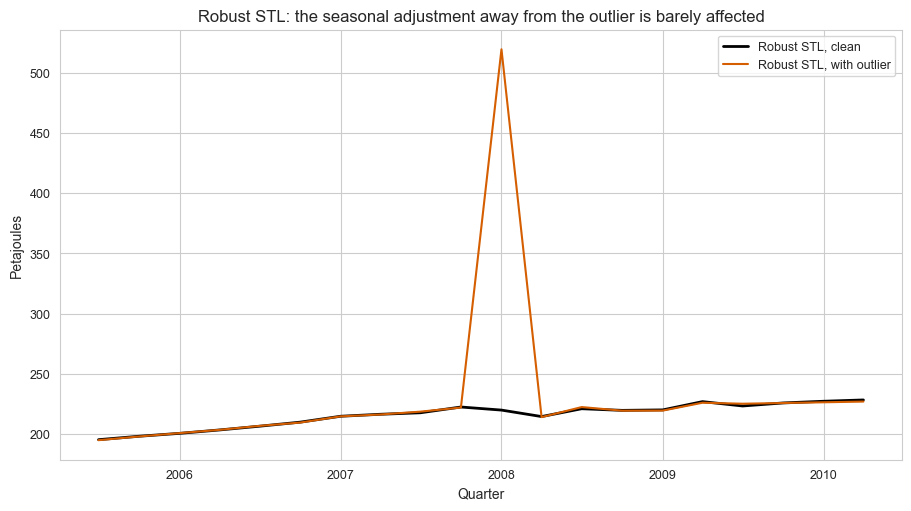

Spill-over onto the other 19 observations, mid-series outlier of +300:
  robust STL                   mean   0.57   max   1.87
  classical seasonal_decompose mean  20.17   max  43.83


In [33]:
# STL with robust=True barely notices the same outlier.
stl_clean = STL(gas_ts, period=4, robust=True).fit()
stl_dirty = STL(gas_mid, period=4, robust=True).fit()

fig, ax = plt.subplots()
ax.plot(gas_ts.index, gas_ts - stl_clean.seasonal, color=BLACK, lw=2, label="Robust STL, clean")
ax.plot(gas_ts.index, gas_mid - stl_dirty.seasonal, color=ORANGE, label="Robust STL, with outlier")
ax.set(title="Robust STL: the seasonal adjustment away from the outlier is barely affected",
       xlabel="Quarter", ylabel="Petajoules")
ax.legend()
plt.show()

sa_r_clean = gas_ts - stl_clean.seasonal
sa_r_dirty = gas_mid - stl_dirty.seasonal
robust_spill = (sa_r_dirty - sa_r_clean).abs().drop(gas_ts.index[mid_pos])

classical_diff = (scenarios["middle (pos 10)"][1] - sa_orig).abs()
classical_spill = classical_diff.drop(classical_diff.index[mid_pos])

print("Spill-over onto the other 19 observations, mid-series outlier of +300:")
print(f"  robust STL                   mean {robust_spill.mean():6.2f}   max {robust_spill.max():6.2f}")
print(f"  classical seasonal_decompose mean {classical_spill.mean():6.2f}   max {classical_spill.max():6.2f}")

---
## Exercise 8

*Recall your retail time series data (from Exercise 7 in Section 2.10). Decompose the series using the
MSTL method. Does it reveal any outliers, or unusual features that you had not noticed previously?*

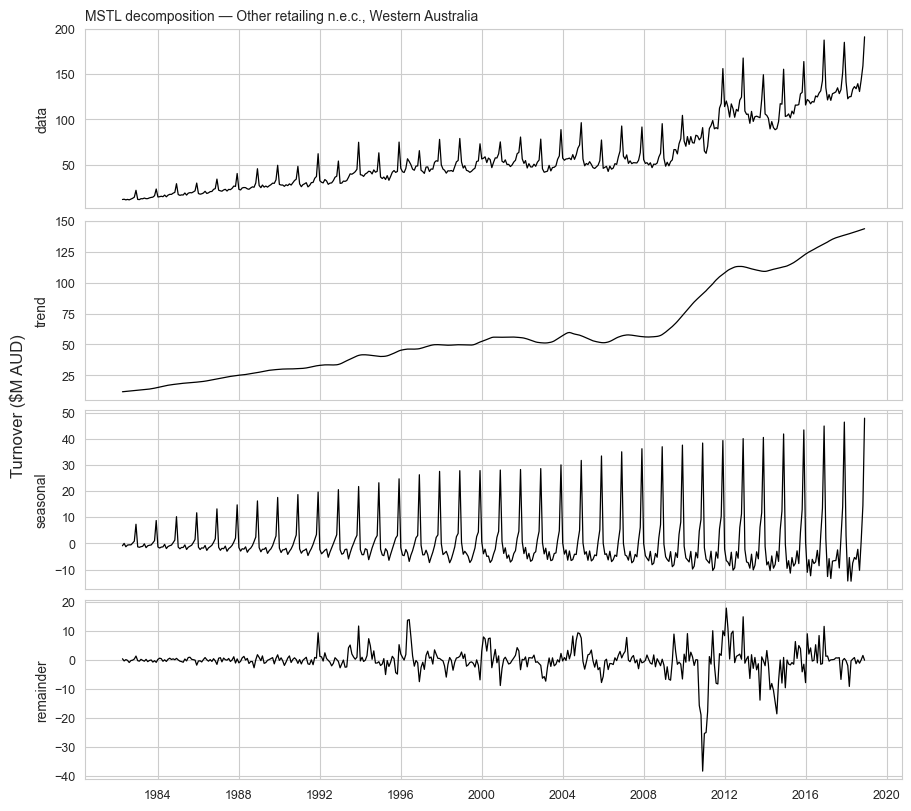

In [34]:
retail_ts = myseries.set_index("ds")["y"].asfreq("MS")

mstl_res = MSTL(retail_ts, periods=12, stl_kwargs={"robust": True}).fit()

retail_dcmp = pd.DataFrame({
    "ds": retail_ts.index,
    "data": retail_ts.to_numpy(),
    "trend": np.asarray(mstl_res.trend).ravel(),
    "seasonal": np.asarray(mstl_res.seasonal).ravel(),
    "remainder": np.asarray(mstl_res.resid).ravel(),
})

decomposition_plot(retail_dcmp, ["data", "trend", "seasonal", "remainder"],
                   f"MSTL decomposition — {myseries['Industry'].iloc[0]}, {myseries['State'].iloc[0]}",
                   ylabel="Turnover ($M AUD)")
plt.show()

In [35]:
# A naive 3-sigma rule on the remainder.
resid = retail_dcmp["remainder"]
sigma = 1.4826 * (resid - resid.median()).abs().median()
n_flagged = ((resid - resid.median()).abs() > 3 * sigma).sum()
print(f"Robust sigma = {sigma:.3f};  {n_flagged} of {len(resid)} observations beyond 3 sigma "
      f"({100 * n_flagged / len(resid):.0f}%)")
print("-> far too many to call 'outliers'. That is itself the first finding.")

Robust sigma = 1.585;  71 of 441 observations beyond 3 sigma (16%)
-> far too many to call 'outliers'. That is itself the first finding.


In [36]:
# Is the remainder homoscedastic? Compare its spread decade by decade.
spread = (
    retail_dcmp.assign(decade=lambda x: (x["ds"].dt.year // 10) * 10)
    .groupby("decade")
    .agg(level=("data", "mean"), resid_sd=("remainder", "std"))
)
spread["resid_sd_pct_of_level"] = 100 * spread["resid_sd"] / spread["level"]
print(spread.round(3).to_string())

          level  resid_sd  resid_sd_pct_of_level
decade                                          
1980     20.530     0.738                  3.593
1990     41.458     3.221                  7.770
2000     56.398     3.554                  6.301
2010    114.122     8.006                  7.015


The remainder's spread grows roughly in step with the level, so a single global σ is meaningless — it
is set by the quiet 1980s and then flags most of the 2010s. Two fixes, both worth doing: decompose the
**log** of the series (which is what Exercise 4 recommended anyway), and standardise against a
**rolling** robust scale rather than a global one.

In [37]:
log_res = MSTL(np.log(retail_ts), periods=12, stl_kwargs={"robust": True}).fit()
log_dcmp = pd.DataFrame({
    "ds": retail_ts.index,
    "log_data": np.log(retail_ts).to_numpy(),
    "trend": np.asarray(log_res.trend).ravel(),
    "seasonal": np.asarray(log_res.seasonal).ravel(),
    "remainder": np.asarray(log_res.resid).ravel(),
})

r = log_dcmp.set_index("ds")["remainder"]
W = 61   # ~5 years, centred
local_scale = 1.4826 * (r - r.rolling(W, center=True, min_periods=25).median()).abs() \
                         .rolling(W, center=True, min_periods=25).median()
log_dcmp["z"] = ((r - r.median()) / local_scale).to_numpy()

n_flagged = (log_dcmp["z"].abs() > 3).sum()
print(f"After logging and using a rolling scale: {n_flagged} of {len(log_dcmp)} beyond 3 sigma\n")

top = log_dcmp.reindex(log_dcmp["z"].abs().sort_values(ascending=False).index).head(12)
top = top.assign(turnover=retail_ts.reindex(top["ds"]).to_numpy())
print(top[["ds", "turnover", "remainder", "z"]].to_string(index=False))

After logging and using a rolling scale: 30 of 441 beyond 3 sigma

        ds  turnover  remainder       z
2010-12-01      90.9     -0.418 -10.589
2011-01-01      65.1     -0.351  -9.388
2011-02-01      62.4     -0.343  -9.196
2011-03-01      70.3     -0.294  -8.549
1996-06-01      53.4      0.329   7.065
1996-05-01      56.4      0.280   6.037
2010-11-01      79.9     -0.225  -5.698
1994-06-01      42.6      0.224   4.800
2010-10-01      77.4     -0.189  -4.797
2000-02-01      57.0      0.167   4.389
1991-12-01      62.0      0.160   4.360
1996-07-01      49.9      0.203   4.354


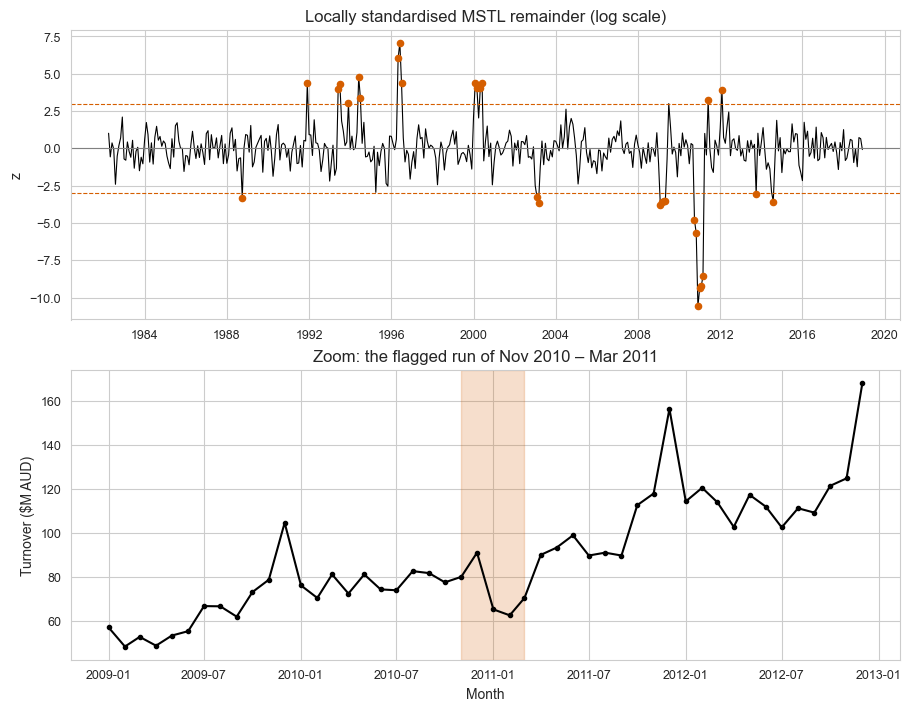

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7))
axes[0].plot(log_dcmp["ds"], log_dcmp["z"], color=BLACK, lw=0.8)
axes[0].axhline(0, color="grey", lw=0.8)
for k in (-3, 3):
    axes[0].axhline(k, color=ORANGE, ls="--", lw=0.8)
flagged = log_dcmp.loc[log_dcmp["z"].abs() > 3]
axes[0].scatter(flagged["ds"], flagged["z"], color=ORANGE, zorder=5, s=20)
axes[0].set(title="Locally standardised MSTL remainder (log scale)", ylabel="z")

# Zoom on the biggest cluster.
zoom = retail_ts.loc["2009-01":"2012-12"]
axes[1].plot(zoom.index, zoom.values, color=BLACK, marker="o", ms=3)
axes[1].axvspan(pd.Timestamp("2010-11-01"), pd.Timestamp("2011-03-01"), color=ORANGE, alpha=0.2)
axes[1].set(title="Zoom: the flagged run of Nov 2010 – Mar 2011", xlabel="Month",
            ylabel="Turnover ($M AUD)")
plt.show()

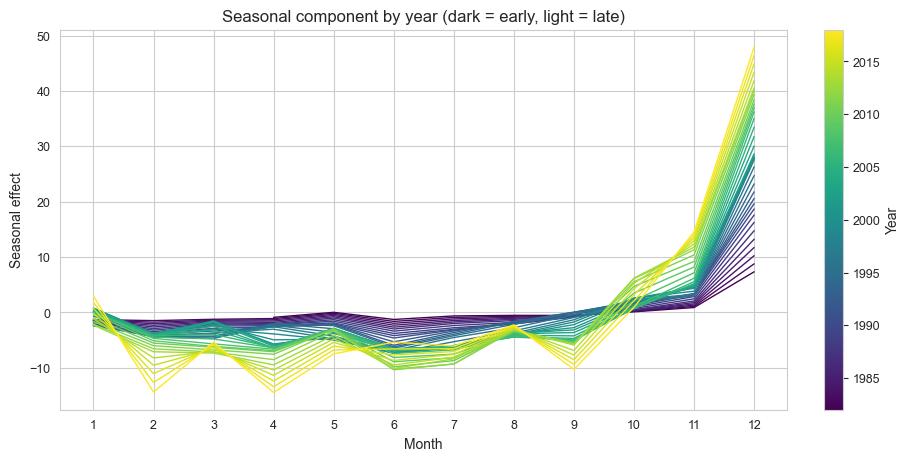

In [39]:
# How much has the seasonal shape changed over the life of the series?
seas_by_year = (
    retail_dcmp.assign(year=lambda x: x["ds"].dt.year, month=lambda x: x["ds"].dt.month)
    .pivot_table(index="month", columns="year", values="seasonal")
)
yr_min, yr_max = seas_by_year.columns.min(), seas_by_year.columns.max()

fig, ax = plt.subplots(figsize=(9, 4.5))
for yr in seas_by_year.columns:
    ax.plot(seas_by_year.index, seas_by_year[yr],
            color=plt.cm.viridis((yr - yr_min) / (yr_max - yr_min)), lw=1)
ax.set(title="Seasonal component by year (dark = early, light = late)",
       xlabel="Month", ylabel="Seasonal effect", xticks=range(1, 13))
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(yr_min, yr_max))
fig.colorbar(sm, ax=ax, label="Year")
plt.show()

**Answer.** The decomposition surfaces four things a plot of the raw series hides.

- **The remainder is badly heteroscedastic.** Its standard deviation grows from about 0.7 in the 1980s
  to about 8.0 in the 2010s, tracking the level of the series. That is why the naive 3σ rule flags
  16% of all months. Because MSTL here is additive on untransformed data, this is exactly the
  variance-grows-with-level problem Exercise 4 diagnosed — and a direct argument for decomposing the
  **log** rather than the raw turnover.
- **One dominant anomaly: a run, not a spike.** After logging and standardising locally, the top of the
  ranking is not a scatter of isolated months but a consecutive block. The four largest |z| values are
  **Dec 2010, Jan 2011, Feb 2011 and Mar 2011** (|z| ≈ 10.6, 9.4, 9.2, 8.5), with Nov 2010 and Oct 2010
  also in the top ten. Over those five months turnover ran roughly 20–34% below what trend plus
  seasonality implied, and then snapped straight back in April 2011. A sustained dip followed by full
  recovery is not measurement noise; it looks like a genuine disruption or a
  reporting/reclassification change in this series. A second, smaller cluster sits in May–July 1996.
  Neither is visible in the raw level plot, because the ordinary seasonal swing is larger than the
  anomaly itself.
- **The seasonal shape is not fixed.** The year-by-year seasonal plot fans out: the December peak grows
  steadily in absolute terms across the series. MSTL/STL permit exactly this, which is why they fit
  here and a classical decomposition with one set of seasonal indices would not.
- **The trend is not monotone.** Once the seasonal swing is stripped away, flat and declining stretches
  become legible that the raw plot buries under the seasonal variation.

Note the methodological lesson in the first two points: an outlier rule is only as good as the scale it
is compared against. The same MSTL fit yields "16% of months are outliers" or "one clear five-month
anomaly" depending entirely on whether the remainder's changing spread is accounted for.

---
## Exercise 9

*Figures 3.15 and 3.16 show the result of decomposing the number of persons in the civilian labour
force in Australia each month from February 1978 to August 1995.*

*(a) Write about 3–5 sentences describing the results of the decomposition. Pay particular attention
to the scales of the graphs in making your interpretation. (b) Is the recession of 1991/1992 visible
in the estimated components?*

The book presents these as figures only. Reproduced below from the same series (`labour` in the R
`fma` package) so the scales can be inspected directly.

Feb 1978 to Aug 1995  (211 months)


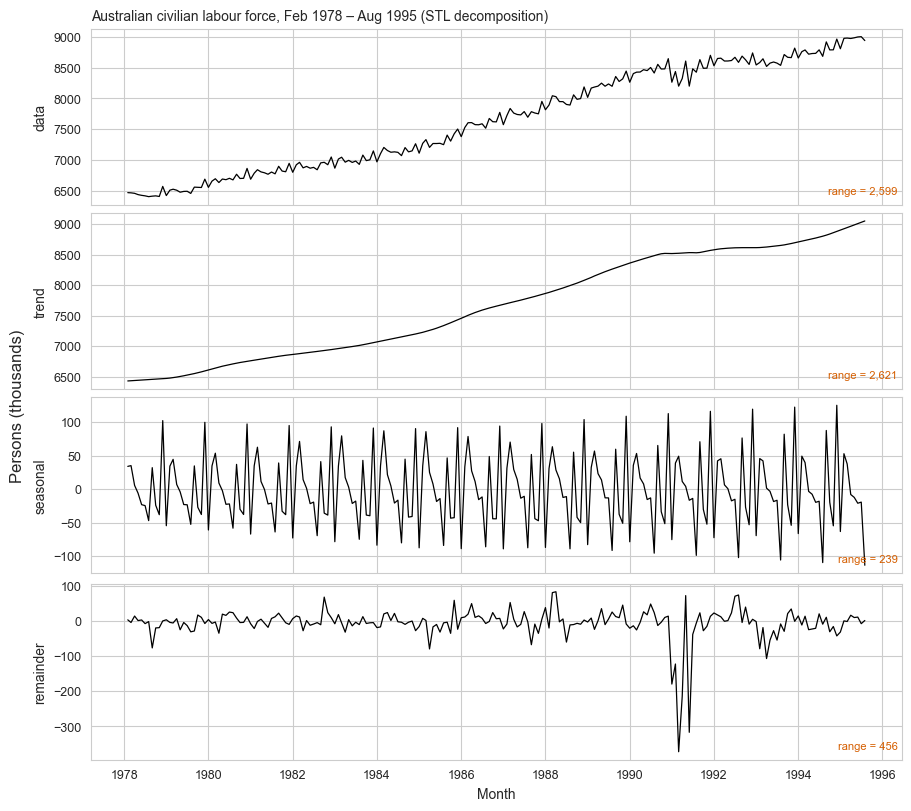

In [40]:
labour_ts = labour.set_index("Month")["Persons"].asfreq("MS")
print(f"{labour_ts.index.min():%b %Y} to {labour_ts.index.max():%b %Y}  ({len(labour_ts)} months)")

stl_lab = STL(labour_ts, period=12, seasonal=13, robust=True).fit()
lab_dcmp = pd.DataFrame({
    "ds": labour_ts.index,
    "data": labour_ts.to_numpy(),
    "trend": stl_lab.trend.to_numpy(),
    "seasonal": stl_lab.seasonal.to_numpy(),
    "remainder": stl_lab.resid.to_numpy(),
})

# Figure 3.15 equivalent. The printed range on each panel plays the role of the
# book's grey scale bars: it shows how large each component is in absolute terms.
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(9, 8))
for ax, col in zip(axes, ["data", "trend", "seasonal", "remainder"]):
    ax.plot(lab_dcmp["ds"], lab_dcmp[col], color=BLACK, lw=0.9)
    ax.set_ylabel(col)
    span = lab_dcmp[col].max() - lab_dcmp[col].min()
    ax.text(0.995, 0.06, f"range = {span:,.0f}", transform=ax.transAxes,
            ha="right", fontsize=8, color=ORANGE)
axes[0].set_title("Australian civilian labour force, Feb 1978 – Aug 1995 (STL decomposition)",
                  size="medium", loc="left")
axes[-1].set_xlabel("Month")
fig.supylabel("Persons (thousands)")
plt.show()

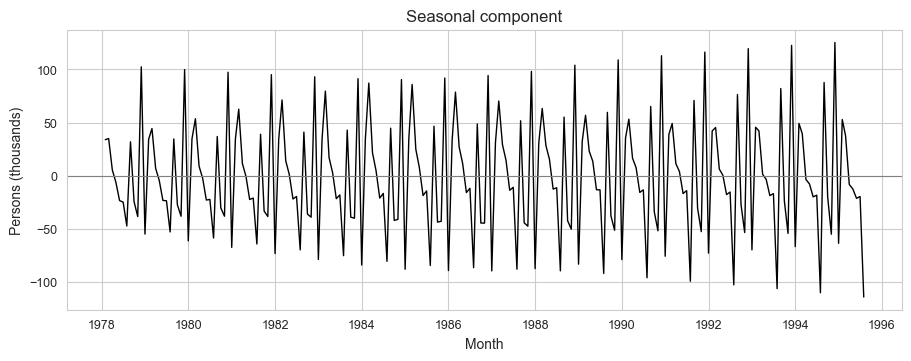

Size of each component, in thousands of persons:
            range     sd     IQR
data       2599.4  819.7  1571.1
trend      2620.7  822.9  1621.1
seasonal    239.1   55.1    76.1
remainder   456.1   47.1    24.8


In [41]:
# Figure 3.16 equivalent: the seasonal component on its own.
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(lab_dcmp["ds"], lab_dcmp["seasonal"], color=BLACK, lw=1)
ax.axhline(0, color="grey", lw=0.8)
ax.set(title="Seasonal component", xlabel="Month", ylabel="Persons (thousands)")
plt.show()

comp = lab_dcmp[["data", "trend", "seasonal", "remainder"]]
print("Size of each component, in thousands of persons:")
print(pd.DataFrame({
    "range": comp.max() - comp.min(),
    "sd": comp.std(),
    "IQR": comp.quantile(0.75) - comp.quantile(0.25),
}).round(1).to_string())

In [42]:
# The remainder's range is far larger than its typical spread -- where does it come from?
big = lab_dcmp.set_index("ds")["remainder"].abs().nlargest(6)
print("Six largest |remainder| values:")
print(big.round(1).to_string())

r = lab_dcmp.set_index("ds")["remainder"]
print(f"\nsd(remainder), 1978-1990 : {r.loc['1978':'1990'].std():6.1f}")
print(f"sd(remainder), 1991-1992 : {r.loc['1991':'1992'].std():6.1f}")
print(f"sd(remainder), 1993-1995 : {r.loc['1993':'1995'].std():6.1f}")

# And is the seasonal amplitude really drifting?
sy = lab_dcmp.set_index("ds")["seasonal"].groupby(lab_dcmp["ds"].dt.year.values) \
             .agg(lambda x: x.max() - x.min())
print(f"\nSeasonal peak-to-trough: {sy.loc[1978]:.0f} in 1978 -> {sy.loc[1994]:.0f} in 1994")

Six largest |remainder| values:
ds
1991-03-01    372.2
1991-06-01    316.9
1991-04-01    213.9
1991-01-01    179.4
1991-02-01    122.2
1993-04-01    106.6

sd(remainder), 1978-1990 :   23.5
sd(remainder), 1991-1992 :  117.7
sd(remainder), 1993-1995 :   30.2

Seasonal peak-to-trough: 149 in 1978 -> 235 in 1994


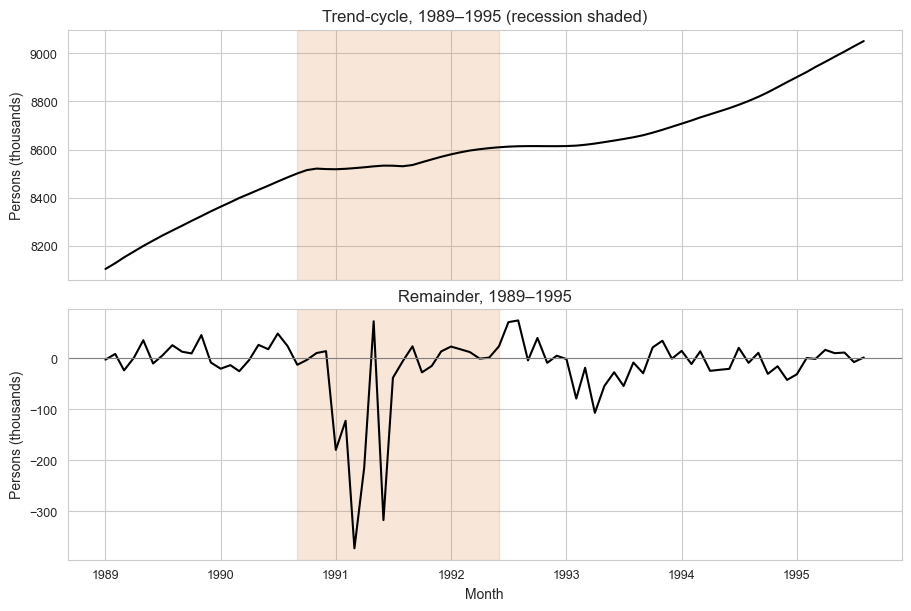

Year-on-year growth of the trend-cycle (%), annual mean:
ds
1978     NaN
1979    1.27
1980    2.49
1981    1.85
1982    1.36
1983    1.42
1984    1.91
1985    2.47
1986    3.58
1987    2.50
1988    2.60
1989    3.28
1990    2.75
1991    0.97
1992    0.82
1993    0.47
1994    1.62
1995    2.54


In [43]:
# Zoom on 1989-1995 to look for the recession.
window = lab_dcmp.loc[lab_dcmp["ds"].between("1989-01-01", "1995-08-01")]
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(window["ds"], window["trend"], color=BLACK)
axes[0].axvspan(pd.Timestamp("1990-09-01"), pd.Timestamp("1992-06-01"), color=ORANGE, alpha=0.15)
axes[0].set(title="Trend-cycle, 1989–1995 (recession shaded)", ylabel="Persons (thousands)")
axes[1].plot(window["ds"], window["remainder"], color=BLACK)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].axvspan(pd.Timestamp("1990-09-01"), pd.Timestamp("1992-06-01"), color=ORANGE, alpha=0.15)
axes[1].set(title="Remainder, 1989–1995", xlabel="Month", ylabel="Persons (thousands)")
plt.show()

# Year-on-year growth in the trend-cycle, to show the pause explicitly.
growth = lab_dcmp.set_index("ds")["trend"].pct_change(12).mul(100)
print("Year-on-year growth of the trend-cycle (%), annual mean:")
print(growth.groupby(growth.index.year).mean().round(2).to_string())

**(a)** The decomposition is overwhelmingly a **trend** story: the trend-cycle spans about 2,620
thousand persons over the 17 years — essentially the entire range of the data — while the seasonal
component spans only about 240 and has an interquartile range of about 76, and the remainder's typical
spread is smaller still (sd ≈ 24 outside the recession years). Because each panel is drawn on its own
y-axis, the seasonal and remainder plots *look* as dramatic as the data; the grey scale bars in the
book's figure exist precisely to stop that misreading, and the printed ranges above do the same job
here. The labour force grows steadily from about 6.5 million to about 9.0 million, with one visible
pause in the early 1990s. The seasonal pattern keeps its shape but its amplitude drifts upward over
the period (peak-to-trough about 150 in 1978 rising to about 235 by 1994), which is why STL — with its
time-varying seasonal component — suits this series better than a classical decomposition.

One number needs care. The remainder's *range* (456) is nearly twice the seasonal component's (239),
which would seem to say the noise dominates the seasonality. It does not: that range is produced
almost entirely by 1991. The five largest remainders all fall in that single year, and the remainder's
standard deviation jumps from about 24 in 1978–90 to about 118 in 1991–92. Away from the recession the
remainder is small and structureless. This is a good illustration of why range is a poor summary of a
component's size — the sd and IQR tell the right story.

**(b)** **Yes, unmistakably, and in both components.** The trend-cycle flattens through 1991–93: the
year-on-year growth table drops from a steady 2.5–3.5% to 0.97%, 0.82% and 0.47% in 1991, 1992 and
1993 — the only sustained pause in the record. At the same time the remainder explodes, with every one
of its five largest values falling in 1991 (up to about 372 thousand persons) and its standard
deviation rising five-fold. The split between the two is what you would expect from STL: the smooth
part of the downturn is absorbed into the trend-cycle, which in an STL decomposition contains the
cycle as well as the trend, while the abrupt month-to-month departures — too sharp for the trend
window to follow — spill into the remainder.

---
## Exercise 10

*This exercise uses the `canadian_gas` data (monthly Canadian gas production in billions of cubic
metres, January 1960 – February 2005).*

### (a) Plot the data to look at the effect of the changing seasonality over time.

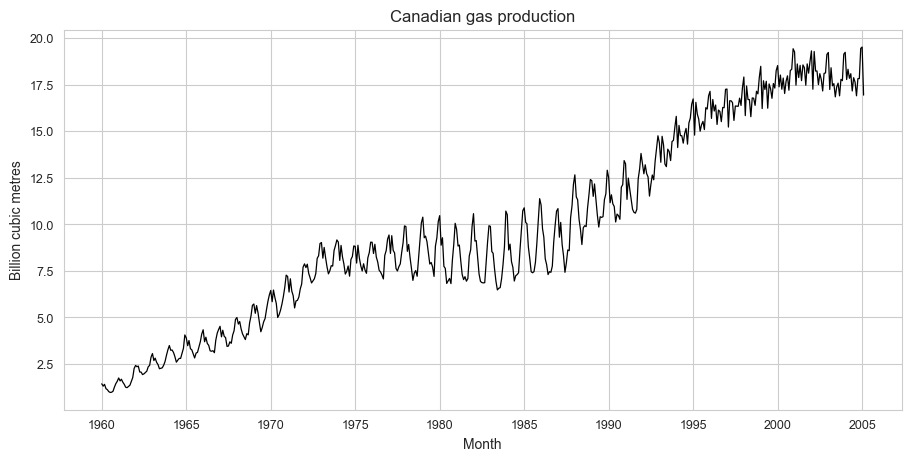

In [44]:
cg = canadian_gas.rename(columns={"Month": "ds", "Volume": "y"}).reset_index(drop=True)
cg_ts = cg.set_index("ds")["y"].asfreq("MS")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cg["ds"], cg["y"], color=BLACK, lw=0.9)
ax.set(title="Canadian gas production", xlabel="Month", ylabel="Billion cubic metres")
plt.show()

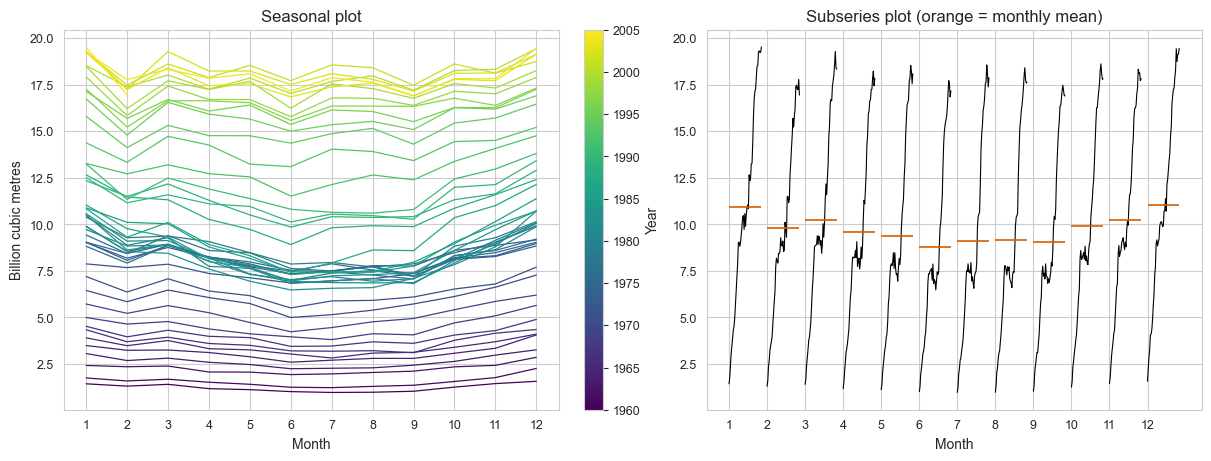

In [45]:
cg = cg.assign(year=lambda x: x["ds"].dt.year, month=lambda x: x["ds"].dt.month)
norm = plt.Normalize(cg["year"].min(), cg["year"].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Seasonal plot: one line per year.
for yr, g in cg.groupby("year"):
    axes[0].plot(g["month"], g["y"], color=plt.cm.viridis(norm(yr)), lw=0.9)
axes[0].set(title="Seasonal plot", xlabel="Month", ylabel="Billion cubic metres",
            xticks=range(1, 13))

# Subseries plot: each month gets its own mini time series.
n_years = cg["year"].nunique()
for m in range(1, 13):
    g = cg.loc[cg["month"] == m]
    xpos = m + (g["year"] - cg["year"].min()) / (n_years * 1.15)
    axes[1].plot(xpos, g["y"], color=BLACK, lw=0.8)
    axes[1].hlines(g["y"].mean(), m, xpos.max(), color=ORANGE, lw=1.2)
axes[1].set(title="Subseries plot (orange = monthly mean)", xlabel="Month", ylabel="",
            xticks=range(1, 13))

sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
fig.colorbar(sm, ax=axes[0], label="Year")
plt.show()

The seasonal plot shows the pattern **changing shape**, not just scale. In the 1960s (dark lines) the
profile is a shallow single winter maximum. By the 1980s (mid-green) the seasonal swing is much larger
and sharply peaked in the winter months with a deep summer trough. In the 1990s and 2000s (yellow) the
level is the highest of all, but the *swing around it* narrows again and the profile loses its clean
shape. This is precisely the non-monotonic behaviour that made a Box-Cox transformation useless in
Exercise 3; part (c) quantifies it.

### (b) Do an STL decomposition of the data using `STL()`.

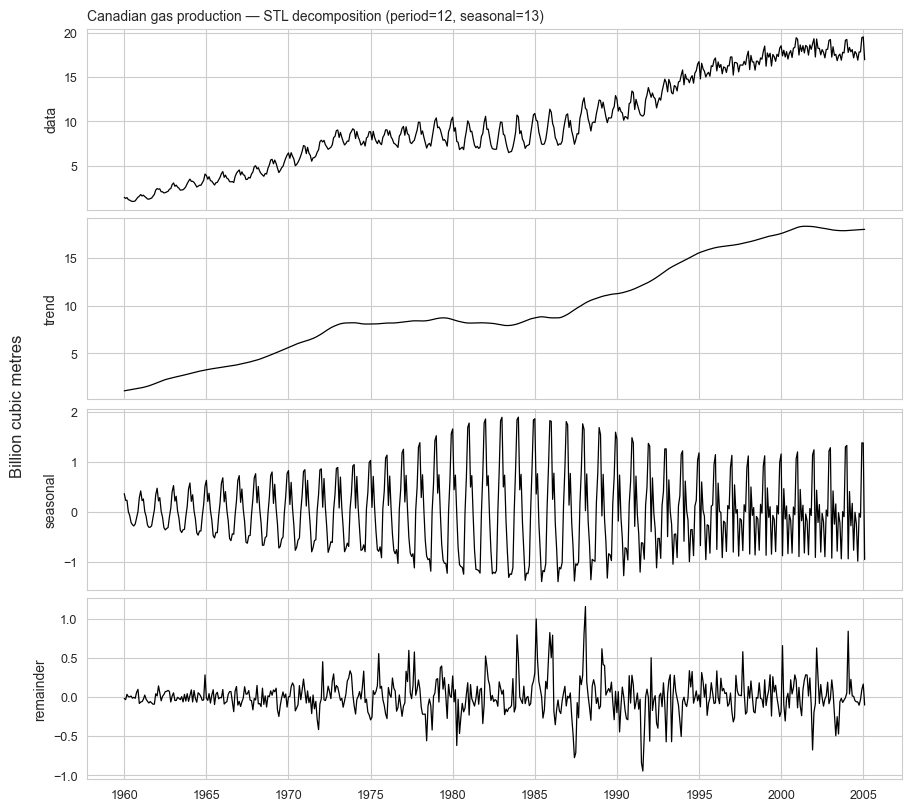

In [46]:
stl_cg = STL(cg_ts, period=12, seasonal=13, trend=25, robust=True).fit()

cg_dcmp = pd.DataFrame({
    "ds": cg_ts.index,
    "data": cg_ts.to_numpy(),
    "trend": stl_cg.trend.to_numpy(),
    "seasonal": stl_cg.seasonal.to_numpy(),
    "remainder": stl_cg.resid.to_numpy(),
})

decomposition_plot(cg_dcmp, ["data", "trend", "seasonal", "remainder"],
                   "Canadian gas production — STL decomposition (period=12, seasonal=13)",
                   ylabel="Billion cubic metres")
plt.show()

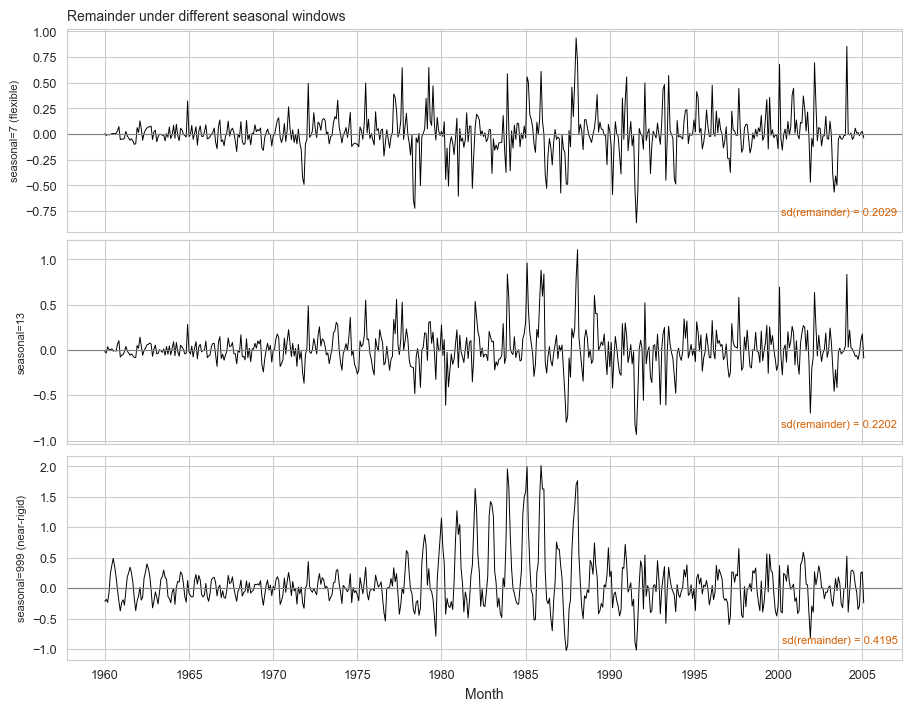

In [47]:
# Compare a rigid seasonal window against flexible ones.
fits = {
    "seasonal=7 (flexible)": STL(cg_ts, period=12, seasonal=7, robust=True).fit(),
    "seasonal=13": STL(cg_ts, period=12, seasonal=13, robust=True).fit(),
    "seasonal=999 (near-rigid)": STL(cg_ts, period=12, seasonal=999, robust=True).fit(),
}
fig, axes = plt.subplots(len(fits), 1, sharex=True, figsize=(9, 7))
for ax, (name, f) in zip(axes, fits.items()):
    ax.plot(cg_ts.index, f.resid, color=BLACK, lw=0.7)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_ylabel(name, fontsize=8)
    ax.text(0.995, 0.08, f"sd(remainder) = {np.std(f.resid):.4f}", transform=ax.transAxes,
            ha="right", fontsize=8, color=ORANGE)
axes[0].set_title("Remainder under different seasonal windows", size="medium", loc="left")
axes[-1].set_xlabel("Month")
plt.show()

A near-rigid seasonal window leaves obvious structure in the remainder — it cannot track the changing
seasonal shape, so the mis-fit leaks through. A short window like `seasonal=7` follows the change
closely but starts absorbing noise. `seasonal=13` is a reasonable compromise.

### (c) How does the seasonal shape change over time?

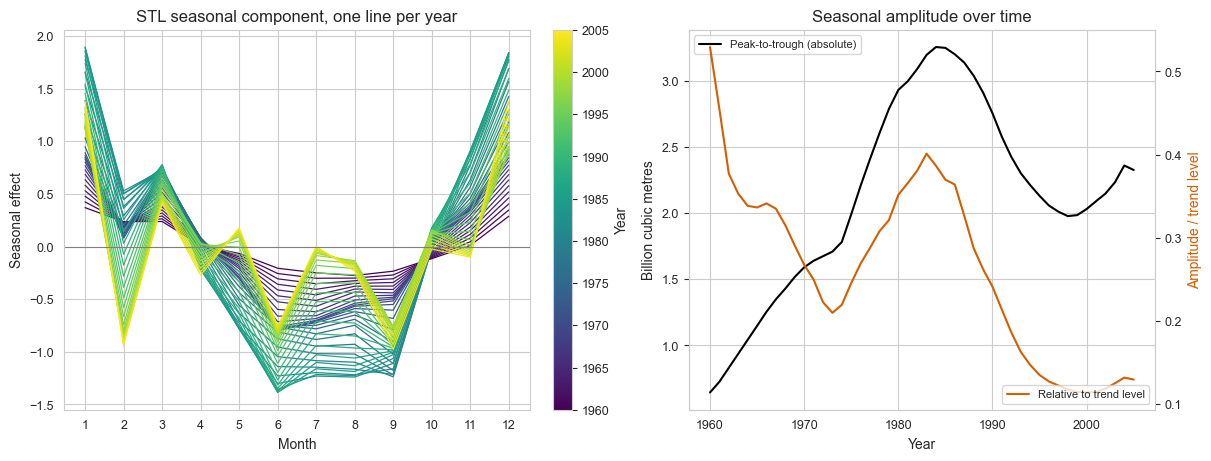

In [48]:
seas = cg_dcmp.assign(year=lambda x: x["ds"].dt.year, month=lambda x: x["ds"].dt.month)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for yr, g in seas.groupby("year"):
    axes[0].plot(g["month"], g["seasonal"], color=plt.cm.viridis(norm(yr)), lw=0.9)
axes[0].axhline(0, color="grey", lw=0.8)
axes[0].set(title="STL seasonal component, one line per year", xlabel="Month",
            ylabel="Seasonal effect", xticks=range(1, 13))

amplitude = seas.groupby("year")["seasonal"].agg(lambda s: s.max() - s.min())
level = seas.groupby("year")["trend"].mean()
axes[1].plot(amplitude.index, amplitude.values, color=BLACK, label="Peak-to-trough (absolute)")
axes[1].set(title="Seasonal amplitude over time", xlabel="Year", ylabel="Billion cubic metres")
ax2 = axes[1].twinx()
ax2.plot(level.index, (amplitude / level).values, color=ORANGE, label="Relative to trend level")
ax2.set_ylabel("Amplitude / trend level", color=ORANGE)
ax2.grid(False)
axes[1].legend(loc="upper left", fontsize=8)
ax2.legend(loc="lower right", fontsize=8)

sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
fig.colorbar(sm, ax=axes[0], label="Year")
plt.show()

In [49]:
print("Seasonal amplitude and its size relative to the trend, averaged by decade:")
by_decade = pd.DataFrame({
    "amplitude": amplitude.groupby(amplitude.index // 10 * 10).mean(),
    "trend_level": level.groupby(level.index // 10 * 10).mean(),
})
by_decade["relative"] = by_decade["amplitude"] / by_decade["trend_level"]
print(by_decade.round(3).to_string())

# Ignore the first and last two years: STL's endpoints are unreliable.
relative = (amplitude / level)
interior = relative.index[(relative.index > 1961) & (relative.index < 2004)]
print(f"\nInterior years only:")
print(f"  absolute amplitude peaks in {amplitude[interior].idxmax()} at {amplitude[interior].max():.3f}")
print(f"  relative amplitude peaks in {relative[interior].idxmax()} at {relative[interior].max():.3f}")
print(f"  relative amplitude by year: "
      + ", ".join(f"{y}: {relative[y]:.3f}" for y in [1965, 1975, 1983, 1990, 2000, 2003]))

Seasonal amplitude and its size relative to the trend, averaged by decade:
      amplitude  trend_level  relative
year                                  
1960      1.087        3.162     0.344
1970      2.038        7.813     0.261
1980      3.099        8.986     0.345
1990      2.242       14.838     0.151
2000      2.197       18.009     0.122

Interior years only:
  absolute amplitude peaks in 1984 at 3.254
  relative amplitude peaks in 1983 at 0.401
  relative amplitude by year: 1965: 0.336, 1975: 0.245, 1983: 0.401, 1990: 0.241, 2000: 0.114, 2003: 0.125


1960-1969: peak month  1, trough month  7, amplitude 1.08, corr with days-in-month -0.00
1975-1984: peak month 12, trough month  9, amplitude 2.68, corr with days-in-month +0.05
1995-2004: peak month  1, trough month  2, amplitude 2.03, corr with days-in-month +0.65


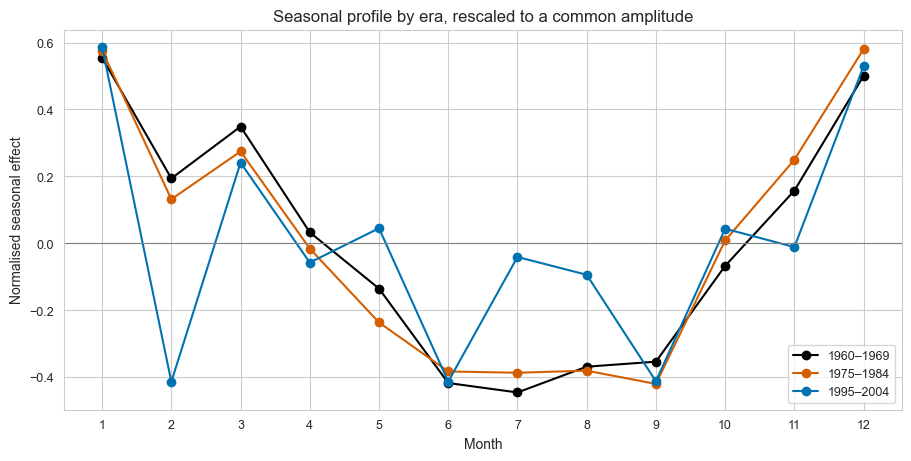

In [50]:
# Has the SHAPE changed, or only the size? Normalise each era's profile.
shape = seas.groupby(["year", "month"])["seasonal"].mean().reset_index()
days_in_month = pd.Series({m: pd.Timestamp(2001, m, 1).days_in_month for m in range(1, 13)})

fig, ax = plt.subplots(figsize=(9, 4.5))
for (lo, hi), color in zip([(1960, 1969), (1975, 1984), (1995, 2004)], [BLACK, ORANGE, BLUE]):
    era = shape.loc[shape["year"].between(lo, hi)].groupby("month")["seasonal"].mean()
    normalised = era / (era.max() - era.min())
    ax.plot(normalised.index, normalised.values, marker="o", color=color, label=f"{lo}–{hi}")
    print(f"{lo}-{hi}: peak month {era.idxmax():>2}, trough month {era.idxmin():>2}, "
          f"amplitude {era.max() - era.min():.2f}, "
          f"corr with days-in-month {era.corr(days_in_month):+.2f}")
ax.axhline(0, color="grey", lw=0.8)
ax.set(title="Seasonal profile by era, rescaled to a common amplitude",
       xlabel="Month", ylabel="Normalised seasonal effect", xticks=range(1, 13))
ax.legend()
plt.show()

**Answer.** Two distinct changes, one in size and one in shape.

1. **Amplitude: up, then down.** The absolute seasonal swing grows from about 1.1 in the 1960s to a
   peak of about 3.25 in **1984** and then falls back to roughly 2.2. Relative to the level the decline
   is far sharper: the ratio fluctuates between roughly 0.25 and 0.40 up to its peak of 0.40 in 1983,
   and then collapses to about 0.12 by 2000 — a drop of some two-thirds, while the level of production
   itself doubled. This rise-then-fall is exactly the non-monotonic variance–level relationship that
   made Box-Cox useless in Exercise 3. (The first and last couple of years are excluded above because
   STL's seasonal estimate is unreliable at the endpoints.)
2. **Shape: from weather to calendar.** Rescaling each era to a common amplitude shows the profile
   itself changing. In the 1960s it is a smooth single winter maximum — peak in January, trough in
   July, with a gradual sinusoidal transition. By 1975–84 it sharpens into a twin December–January
   spike with a deep, flat trough running from June to September. By 1995–2004 that smooth summer
   trough has largely disappeared and the profile becomes jagged, alternating month to month.

   That jaggedness is not noise. The correlation between the late-era seasonal profile and the number
   of days in each month is **+0.65**, against ≈ 0 in both earlier eras: February, June and September
   are the deepest troughs, December and January the highest peaks. As the weather-driven component
   shrank, a **calendar effect** — simply, months have different numbers of days — became a visible
   share of what is left. That is precisely the situation §3.1 recommends fixing with a calendar
   adjustment (model average daily production) before decomposing.

### (d) Can you produce a plausible seasonally adjusted series?

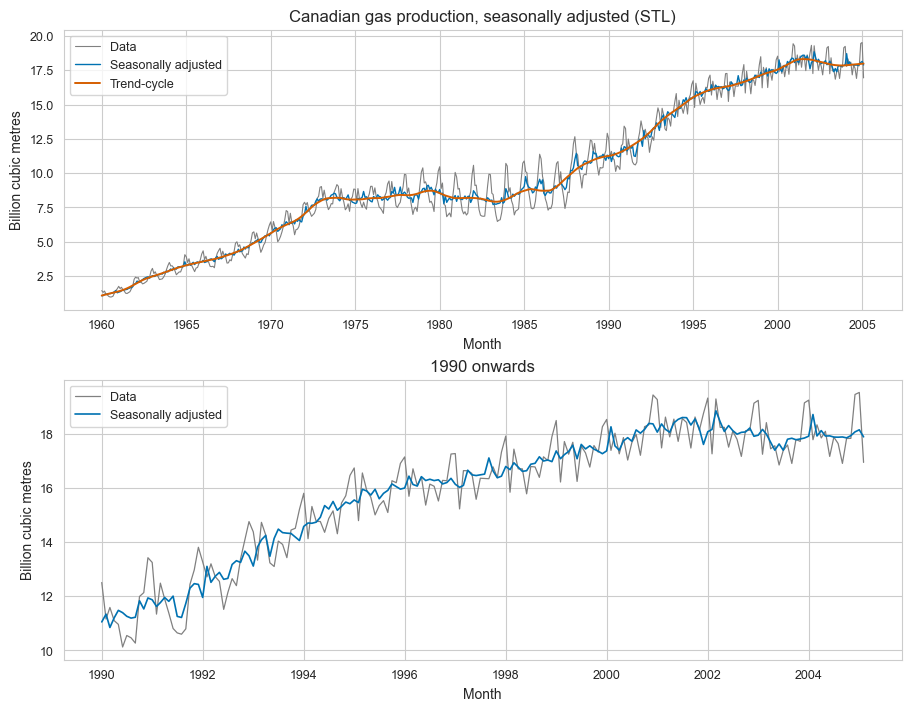

In [51]:
cg_dcmp["seas_adj"] = cg_dcmp["data"] - cg_dcmp["seasonal"]

fig, axes = plt.subplots(2, 1, figsize=(9, 7))
axes[0].plot(cg_dcmp["ds"], cg_dcmp["data"], color="grey", lw=0.8, label="Data")
axes[0].plot(cg_dcmp["ds"], cg_dcmp["seas_adj"], color=BLUE, lw=1, label="Seasonally adjusted")
axes[0].plot(cg_dcmp["ds"], cg_dcmp["trend"], color=ORANGE, lw=1.4, label="Trend-cycle")
axes[0].set(title="Canadian gas production, seasonally adjusted (STL)",
            xlabel="Month", ylabel="Billion cubic metres")
axes[0].legend()

zoom = cg_dcmp.loc[cg_dcmp["ds"] >= "1990-01-01"]
axes[1].plot(zoom["ds"], zoom["data"], color="grey", lw=0.9, label="Data")
axes[1].plot(zoom["ds"], zoom["seas_adj"], color=BLUE, lw=1.2, label="Seasonally adjusted")
axes[1].set(title="1990 onwards", xlabel="Month", ylabel="Billion cubic metres")
axes[1].legend()
plt.show()

In [52]:
# Sanity check: has the seasonality actually been removed?
check = cg_dcmp.assign(month=lambda x: x["ds"].dt.month)
raw_spread = check.groupby("month")["data"].mean()
adj_spread = check.groupby("month")["seas_adj"].mean()

print("Mean by calendar month, before and after adjustment:")
print(pd.DataFrame({"raw": raw_spread, "seasonally_adjusted": adj_spread}).round(3).to_string())
print(f"\nPeak-to-trough of the monthly means -- raw: {raw_spread.max() - raw_spread.min():.3f}, "
      f"adjusted: {adj_spread.max() - adj_spread.min():.3f}")

Mean by calendar month, before and after adjustment:
          raw  seasonally_adjusted
month                             
1      10.948                9.766
2       9.816                9.912
3      10.247                9.656
4       9.612                9.655
5       9.379                9.678
6       8.794                9.671
7       9.107                9.713
8       9.172                9.770
9       9.028                9.831
10      9.895                9.851
11     10.235                9.876
12     11.057                9.921

Peak-to-trough of the monthly means -- raw: 2.263, adjusted: 0.265


In [53]:
# What does a classical decomposition (one fixed seasonal index per month) leave behind?
# Averaged over the whole series both methods look perfect by construction, so compare
# DECADE BY DECADE -- that is where a rigid seasonal index fails.
classical = seasonal_decompose(cg_ts, model="additive", period=12)

resid_seasonality = pd.DataFrame({
    "STL": cg_dcmp.set_index("ds")["seas_adj"] - cg_dcmp.set_index("ds")["trend"],
    "classical": (cg_ts - classical.seasonal) - classical.trend,
}).dropna()

rows = []
for lo, hi in [(1960, 1969), (1970, 1979), (1980, 1989), (1990, 1999), (2000, 2005)]:
    w = resid_seasonality.loc[f"{lo}":f"{hi}"]
    bm = w.groupby(w.index.month).mean()
    rows.append({"decade": f"{lo}s",
                 "STL": round(bm["STL"].max() - bm["STL"].min(), 3),
                 "classical": round(bm["classical"].max() - bm["classical"].min(), 3)})
print("Residual seasonality still present in the adjusted series")
print("(peak-to-trough of the monthly means, within each decade):\n")
print(pd.DataFrame(rows).to_string(index=False))

Residual seasonality still present in the adjusted series
(peak-to-trough of the monthly means, within each decade):

decade   STL  classical
 1960s 0.034      1.064
 1970s 0.165      0.331
 1980s 0.585      1.399
 1990s 0.167      0.854
 2000s 0.491      1.149


**Answer.** Yes. Taking `data − seasonal` from the STL fit gives a plausible seasonally adjusted
series: the monthly means collapse from a peak-to-trough spread of about 2.26 in the raw data to about
0.27 after adjustment, and the adjusted line tracks the trend-cycle closely while retaining genuine
short-run movements — the mid-1970s pause, the dips in the early 2000s — that a pure trend estimate
would smooth away.

STL is the right tool here precisely because it lets the seasonal component evolve, and the last cell
makes the contrast concrete. Averaged over all 45 years a classical decomposition also looks perfect,
because its seasonal indices are *defined* as the average detrended value per month — so that
comparison proves nothing. Broken down by decade the difference is clear: the classical method leaves
between two and thirty times more residual seasonality in every single decade, because one fixed set
of indices cannot be right for a seasonal pattern whose relative size falls by two-thirds over the
record. STL's residual seasonality stays small throughout.

---
## Summary of answers

| Exercise | Result |
|---|---|
| 1 | Monaco leads on GDP per capita in almost every year from 1978 to 2016; Luxembourg tops the 2017 table only because Monaco and Liechtenstein report no 2017 GDP. Earlier leaders: US (early 1960s), Kuwait (1965–66), UAE (1976–77) |
| 2a | US GDP: λ ≈ 0.24 straightens the exponential growth, but no transformation is really needed — prefer a population or inflation adjustment |
| 2b | Victorian bulls/bullocks/steers: λ ≈ −0.05, i.e. a log — but the level–variance link is weak (corr ≈ 0.5) and the gain is small; usable untransformed |
| 2c | `vic_elec`: λ pins at the −0.9 bound while merely removing a mild skew; transformation unhelpful — aggregate to daily and use temperature as a covariate |
| 2d | Australian gas: λ ≈ 0.11, near a log — a strong, worthwhile transformation |
| 3 | Absolute seasonal amplitude rises from ≈ 0.6 (1960s) to ≈ 4.7 (1987) then falls to ≈ 2.5 (2005) while the level keeps rising; one monotonic power transform cannot fix a non-monotonic variance–level relationship |
| 4 | Guerrero λ ≈ 0.22 for A3349908R (WA, other retailing); λ = 0 (log) scores almost identically and is the practical choice |
| 5 | Tobacco λ = 0.93 (none needed); `ansett` MEL–SYD λ pinned at 2.0 — a structural break (7 zero-passenger weeks in 1989), not heteroscedasticity; Southern Cross λ = 0.00, exactly a log (mind the 159 zeros) |
| 6 | 3×5 MA weights = 1/15, 2/15, 3/15, 3/15, 3/15, 2/15, 1/15 = the stated 0.067 … 0.067, matching to 1e−13 on real data |
| 7 | Seasonal indices Q1 0.875, Q2 1.074, Q3 1.126, Q4 0.925. The outlier corrupts the seasonal index for its quarter in *every* year — equally wherever it lands, except at the two extreme ends, where no centred MA exists so it is silently excluded |
| 8 | A global 3σ rule flags 16% of months — the remainder's spread grows 10× with the level. On the log with a rolling scale, one dominant anomaly emerges: a run from Nov 2010 to Mar 2011 |
| 9 | Trend range ≈ 2,620 vs seasonal ≈ 240 (IQR 76) and remainder sd ≈ 24 outside 1991–92; the recession shows as trend growth falling from 2.5–3.5% to 0.5–1.0% and a five-fold jump in remainder sd |
| 10 | Relative seasonal amplitude peaks at ≈ 0.40 in 1983 then falls to ≈ 0.12 by 2000; the shape moves from a smooth winter peak to a sharp twin spike to a jagged calendar-driven profile (corr with days-in-month +0.65 by 1995–2004); `data − seasonal` from STL adjusts well, and beats a classical decomposition in every decade |